# 外気冷房制御参考
気象庁から取り寄せたCSVデータを参考（１時間ごと）

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("data.csv", encoding="cp932")
df['年月日時'] = pd.to_datetime(df['年月日時'])

In [3]:
df

,年月日時,気温(℃),相対湿度(％)
0,2025-01-01 01:00:00,3.8,67.0
1,2025-01-01 02:00:00,4.1,58.0
2,2025-01-01 03:00:00,4.0,53.0
3,2025-01-01 04:00:00,3.4,63.0
4,2025-01-01 05:00:00,3.6,63.0
...,...,...,...
8755,2025-12-31 20:00:00,3.8,84.0
8756,2025-12-31 21:00:00,2.8,89.0
8757,2025-12-31 22:00:00,2.4,90.0
8758,2025-12-31 23:00:00,2.4,89.0


# 年間の気温

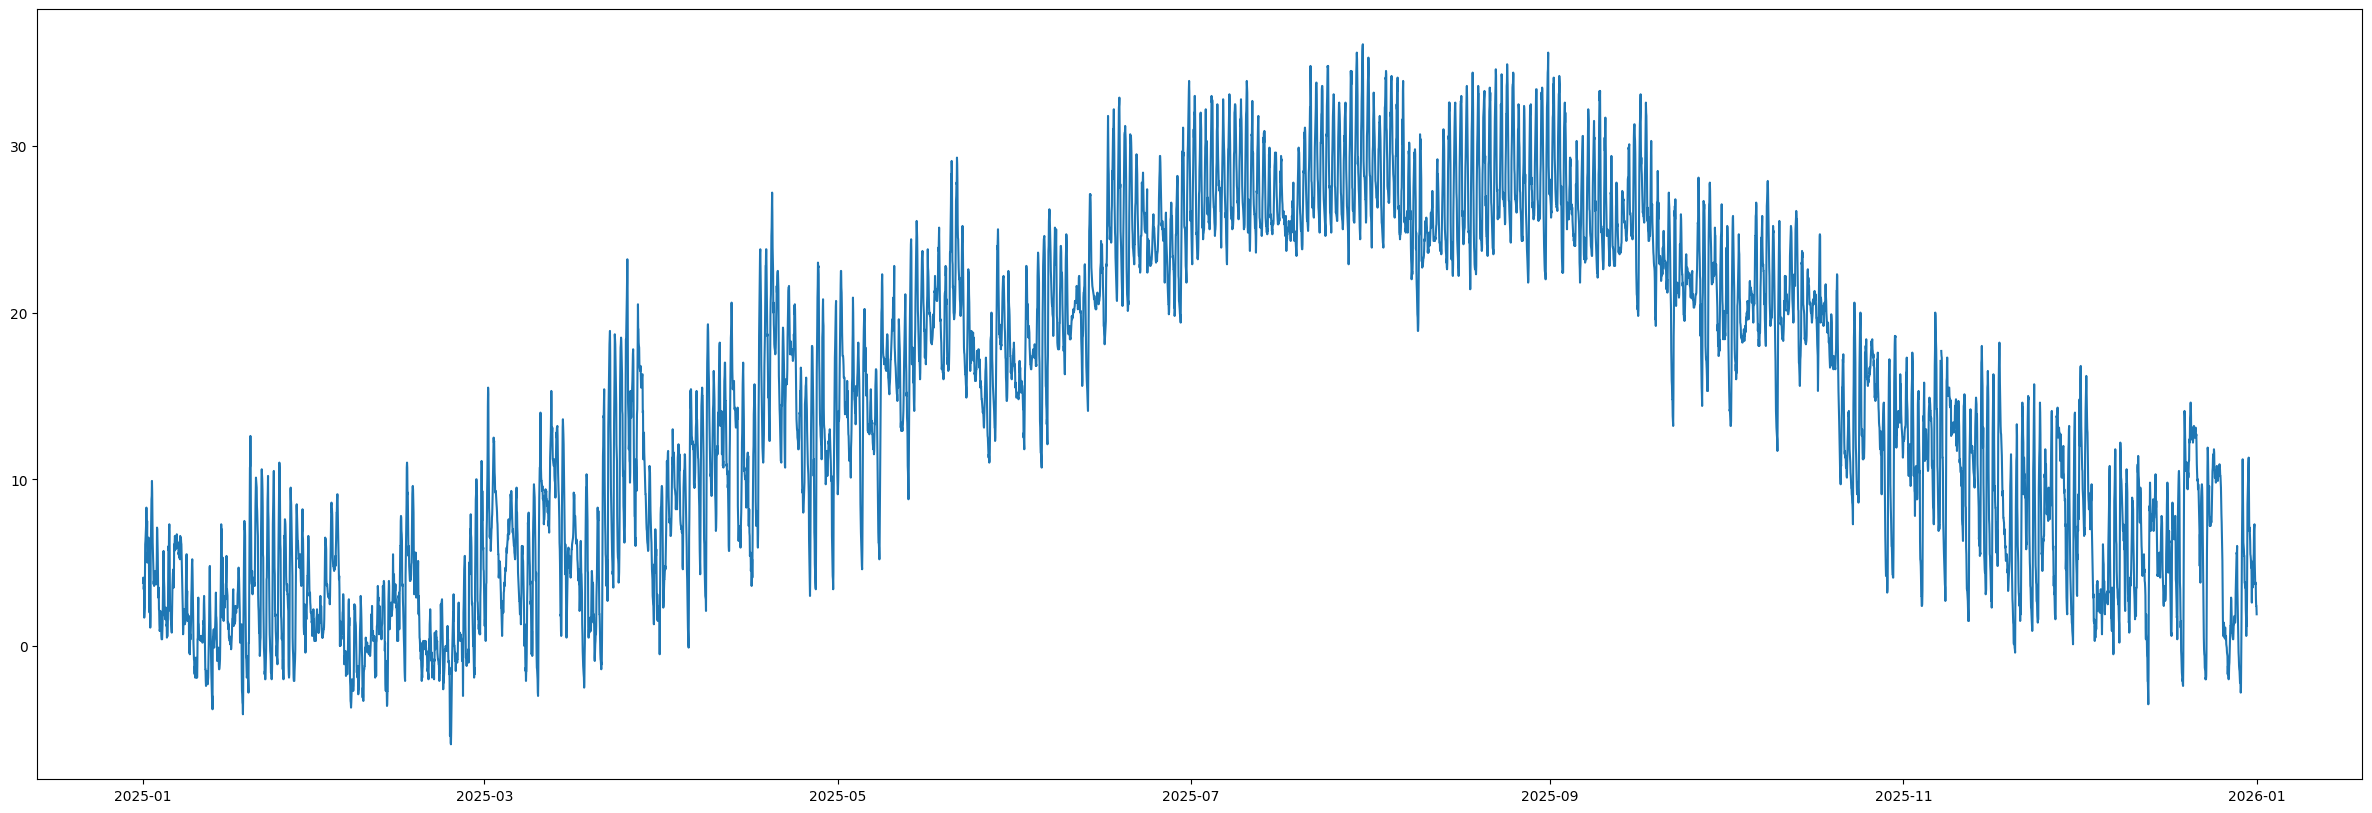

In [4]:
plt.figure(figsize=(30, 10))
plt.plot(df['年月日時'], df['気温(℃)'])
plt.show()

In [5]:
def ent(df_temp, df_rh):
    t = df_temp
    RH = df_rh

    res1 = 237.3 + t
    res2 = 7.5 * t
    res3 = res2 / res1
    res4 = 10.0 ** res3
    res5 = res4 * 6.11
    res6 = res5 * (RH * 0.01)
    res7 = 1013.25 / res6
    res8 = res7 - 1.0
    res9 = 0.00189 * t
    res10 = res9 + 2.5
    res11 = 622.0 * res10
    res12 = res11 / res8
    res13 = 1.01 * t
    df_ans = res12 + res13

    return df_ans

In [6]:
df["エンタルピー"] = ent(df["気温(℃)"], df["相対湿度(％)"])
df

,年月日時,気温(℃),相対湿度(％),エンタルピー
0,2025-01-01 01:00:00,3.8,67.0,12.153598
1,2025-01-01 02:00:00,4.1,58.0,11.490375
2,2025-01-01 03:00:00,4.0,53.0,10.705316
3,2025-01-01 04:00:00,3.4,63.0,11.029602
4,2025-01-01 05:00:00,3.6,63.0,11.341424
...,...,...,...,...
8755,2025-12-31 20:00:00,3.8,84.0,14.277651
8756,2025-12-31 21:00:00,2.8,89.0,13.124439
8757,2025-12-31 22:00:00,2.4,90.0,12.539552
8758,2025-12-31 23:00:00,2.4,89.0,12.426435


# 室内のエンタルピ
## 25.0℃ 50%想定

In [7]:
ent_Indoor = ent(25.0, 50)
print(f"室内のエンタルピ：{ent_Indoor}")

室内のエンタルピ：50.41698388369701


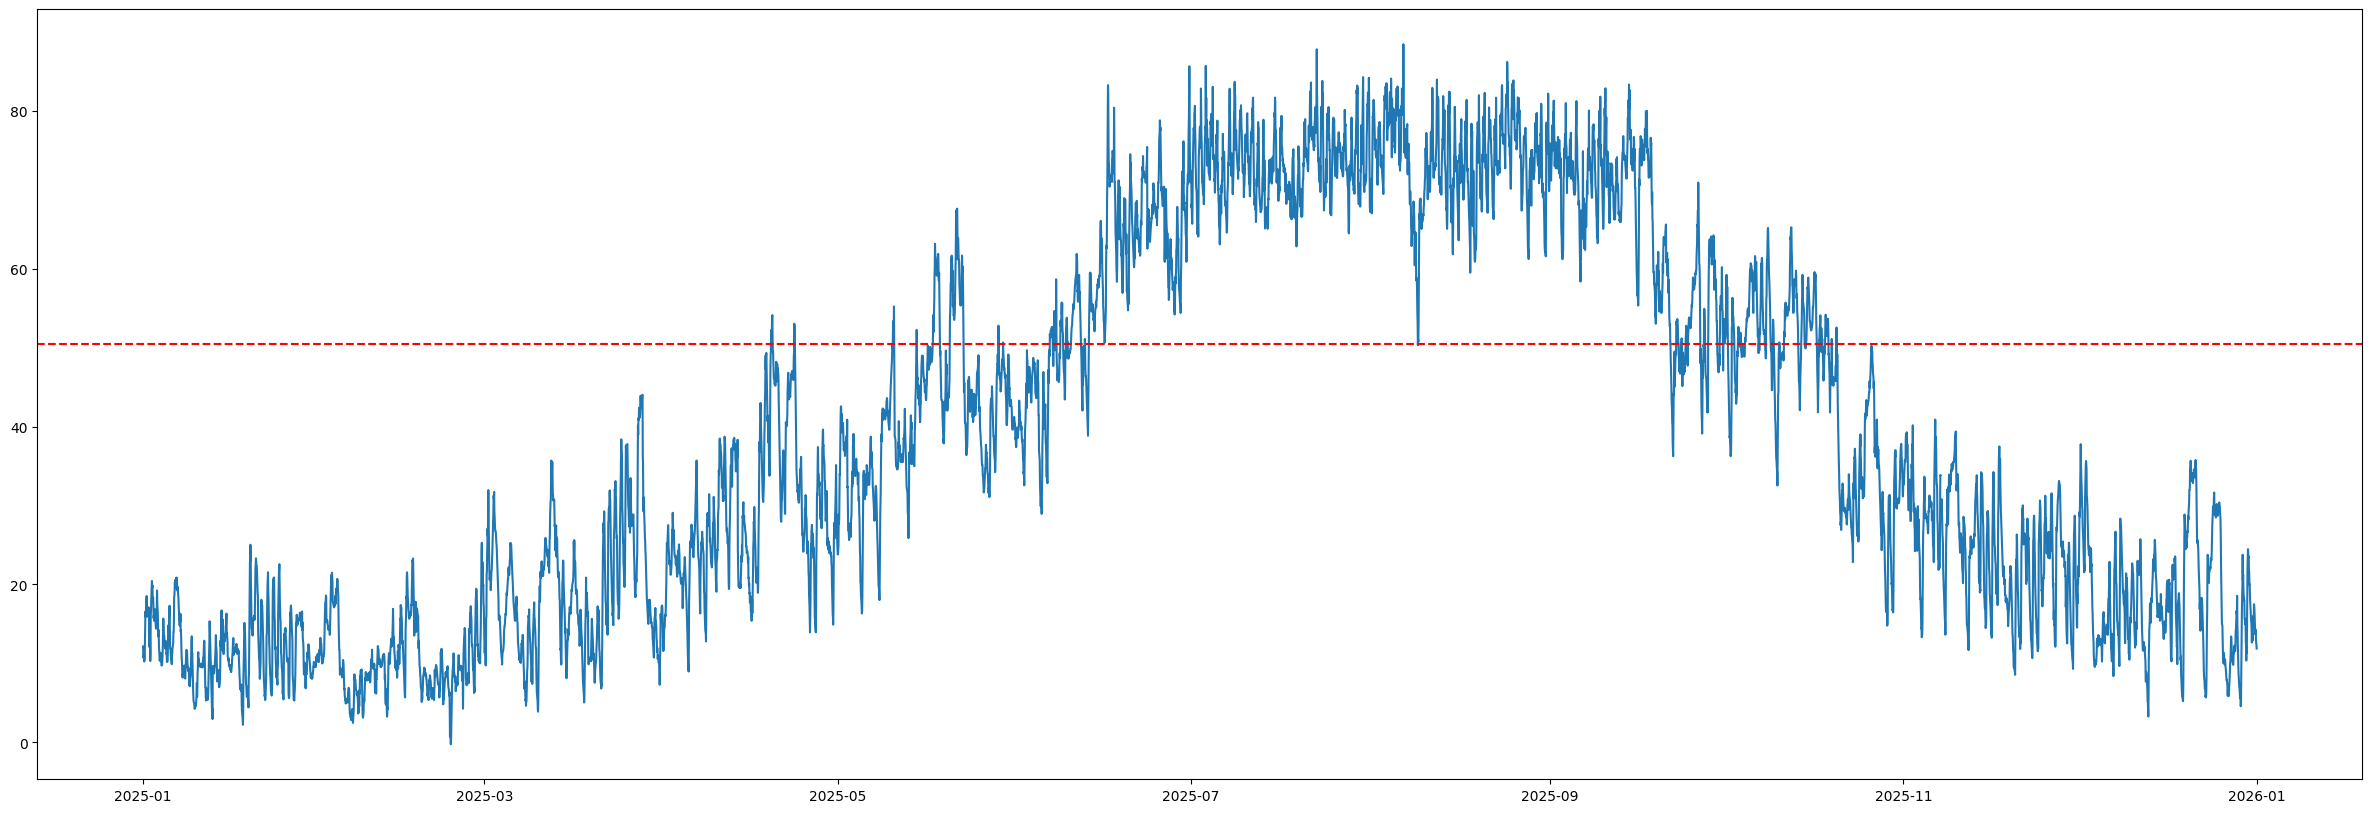

In [8]:
plt.figure(figsize=(30, 10))
plt.plot(df['年月日時'], df['エンタルピー'])
plt.axhline(y=50.41, color='red', linestyle='--')
plt.show()

# 9月のエンタルピ

In [9]:
df_09 = df[(df['年月日時'] >= '2025-09-01') & (df['年月日時'] <= '2025-09-30')]

In [10]:
df_09

,年月日時,気温(℃),相対湿度(％),エンタルピー
5831,2025-09-01 00:00:00,27.1,78.0,72.436126
5832,2025-09-01 01:00:00,26.9,79.0,72.274089
5833,2025-09-01 02:00:00,26.6,80.0,71.727293
5834,2025-09-01 03:00:00,26.4,81.0,71.548402
5835,2025-09-01 04:00:00,25.7,85.0,71.134772
...,...,...,...,...
6523,2025-09-29 20:00:00,20.9,78.0,51.756221
6524,2025-09-29 21:00:00,20.3,76.0,49.233783
6525,2025-09-29 22:00:00,18.9,86.0,48.882453
6526,2025-09-29 23:00:00,19.3,80.0,47.891225


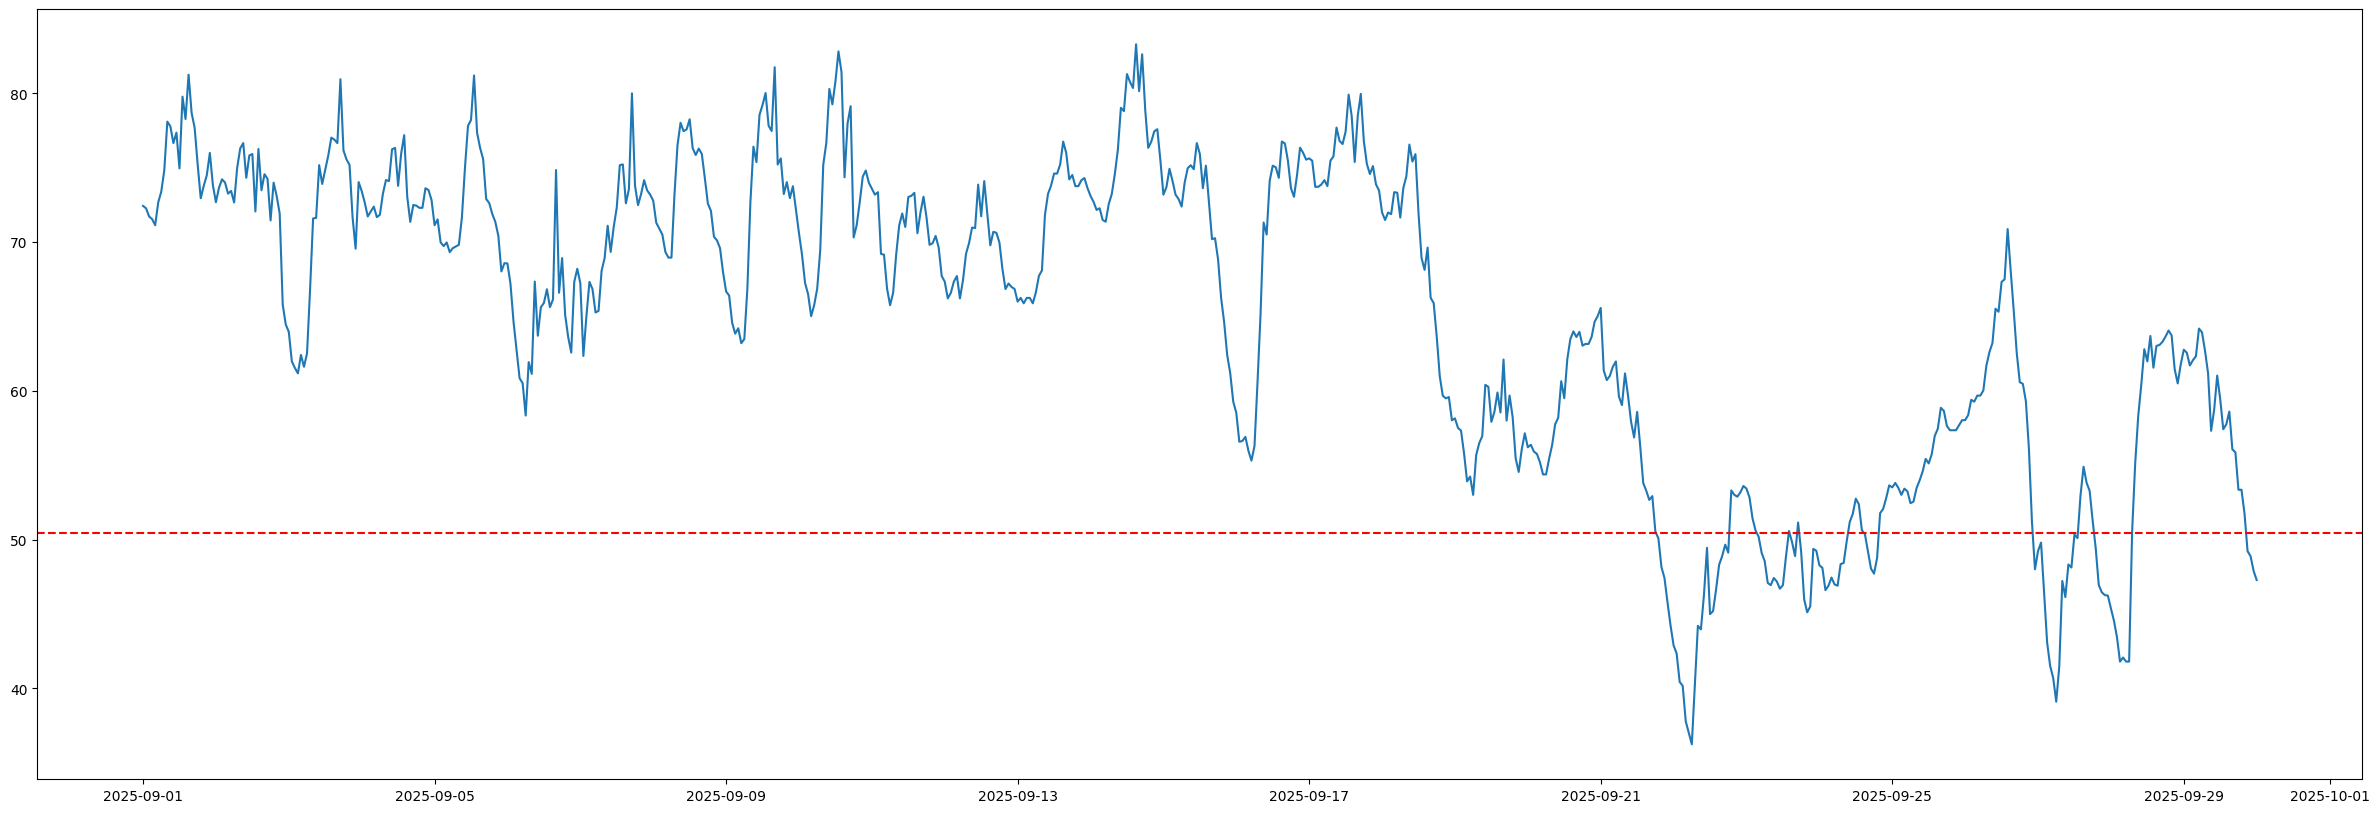

In [11]:
plt.figure(figsize=(30, 10))
plt.plot(df_09['年月日時'], df_09['エンタルピー'])
plt.axhline(y=50.42, color='red', linestyle='--')
plt.show()

# 10月のエンタルピ

In [12]:
df_10 = df[(df['年月日時'] >= '2025-10-01') & (df['年月日時'] <= '2025-10-30')]

In [13]:
df_10

,年月日時,気温(℃),相対湿度(％),エンタルピー
6551,2025-10-01 00:00:00,20.0,84.0,51.412782
6552,2025-10-01 01:00:00,20.1,89.0,53.622981
6553,2025-10-01 02:00:00,20.1,87.0,52.858729
6554,2025-10-01 03:00:00,19.6,91.0,52.808866
6555,2025-10-01 04:00:00,18.4,95.0,50.512626
...,...,...,...,...
7243,2025-10-29 20:00:00,8.2,91.0,23.718657
7244,2025-10-29 21:00:00,7.6,93.0,22.810099
7245,2025-10-29 22:00:00,6.7,95.0,21.285821
7246,2025-10-29 23:00:00,6.0,96.0,20.027370


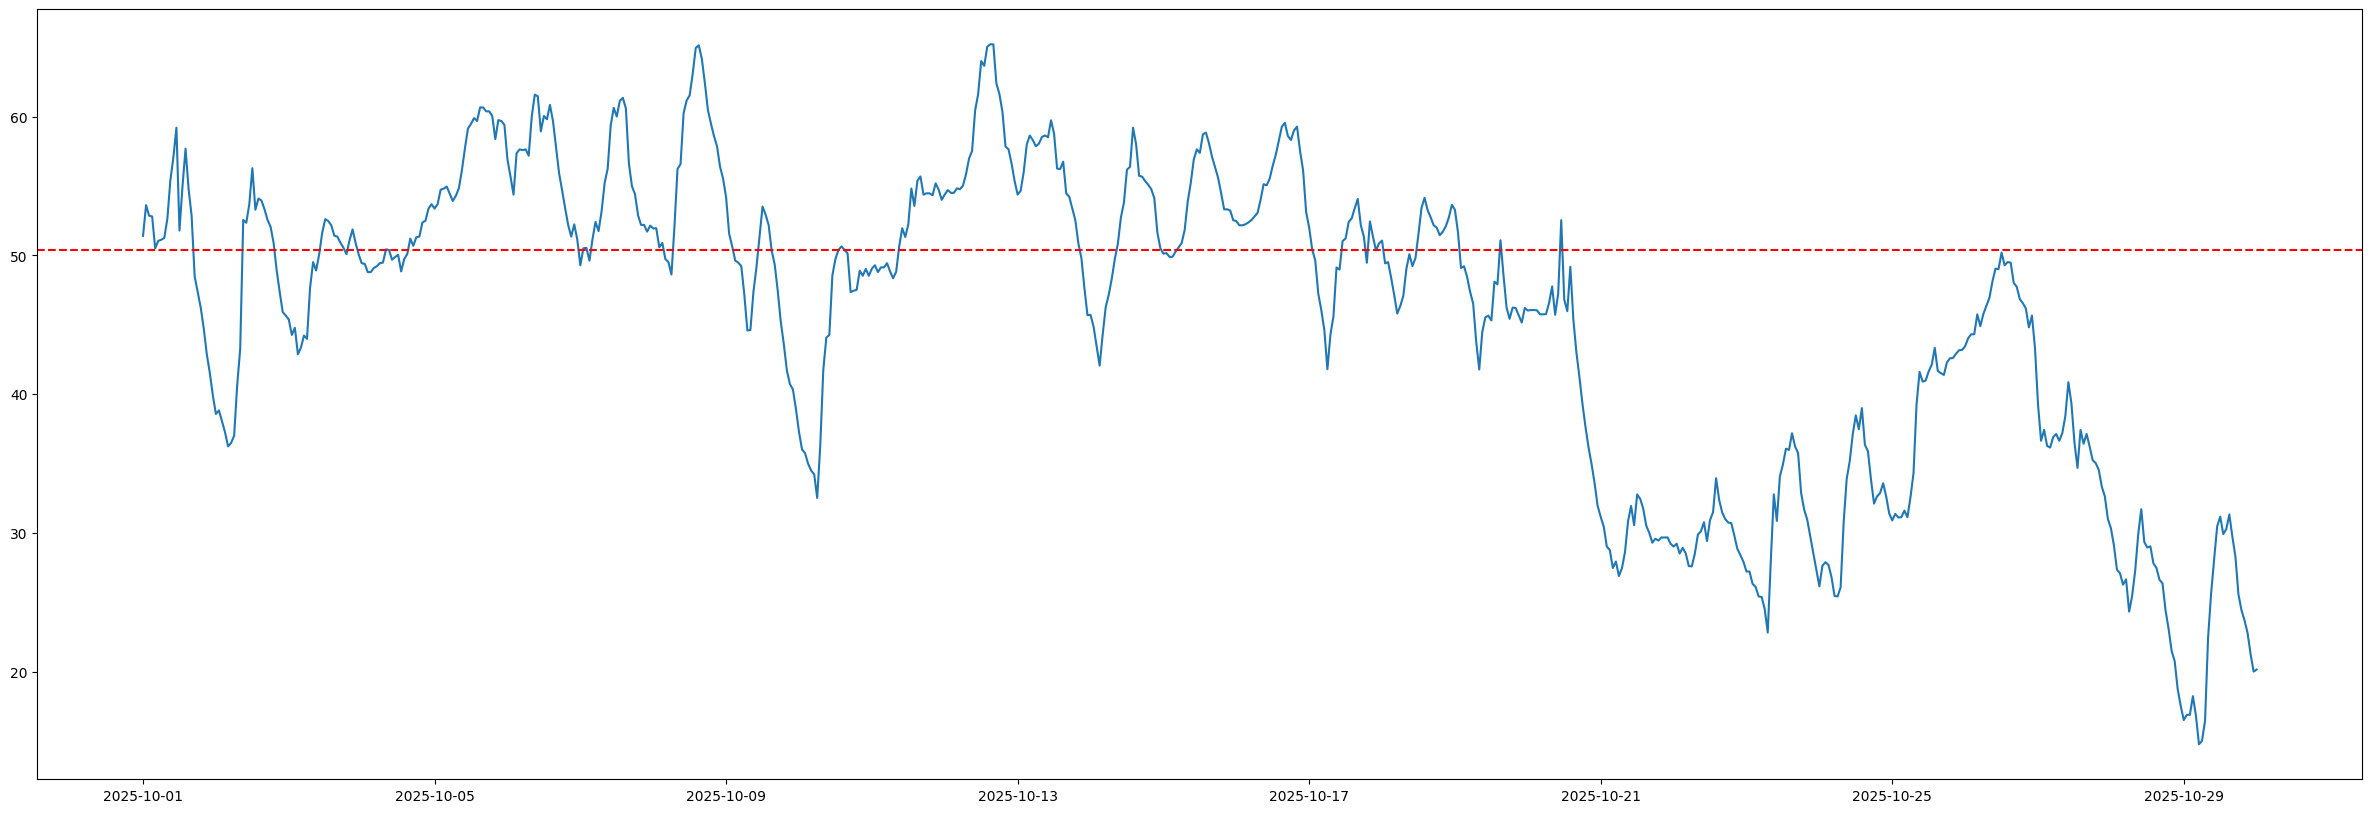

In [14]:
plt.figure(figsize=(30, 10))
plt.plot(df_10['年月日時'], df_10['エンタルピー'])
plt.axhline(y=50.42, color='red', linestyle='--')
plt.show()

# 10月の前半のエンタルピ

In [15]:
df_10_head = df[(df['年月日時'] >= '2025-10-01') & (df['年月日時'] <= '2025-10-15')]
df_10_head

,年月日時,気温(℃),相対湿度(％),エンタルピー
6551,2025-10-01 00:00:00,20.0,84.0,51.412782
6552,2025-10-01 01:00:00,20.1,89.0,53.622981
6553,2025-10-01 02:00:00,20.1,87.0,52.858729
6554,2025-10-01 03:00:00,19.6,91.0,52.808866
6555,2025-10-01 04:00:00,18.4,95.0,50.512626
...,...,...,...,...
6883,2025-10-14 20:00:00,20.1,92.0,54.770720
6884,2025-10-14 21:00:00,19.9,92.0,54.130397
6885,2025-10-14 22:00:00,19.0,93.0,51.666706
6886,2025-10-14 23:00:00,18.4,95.0,50.512626


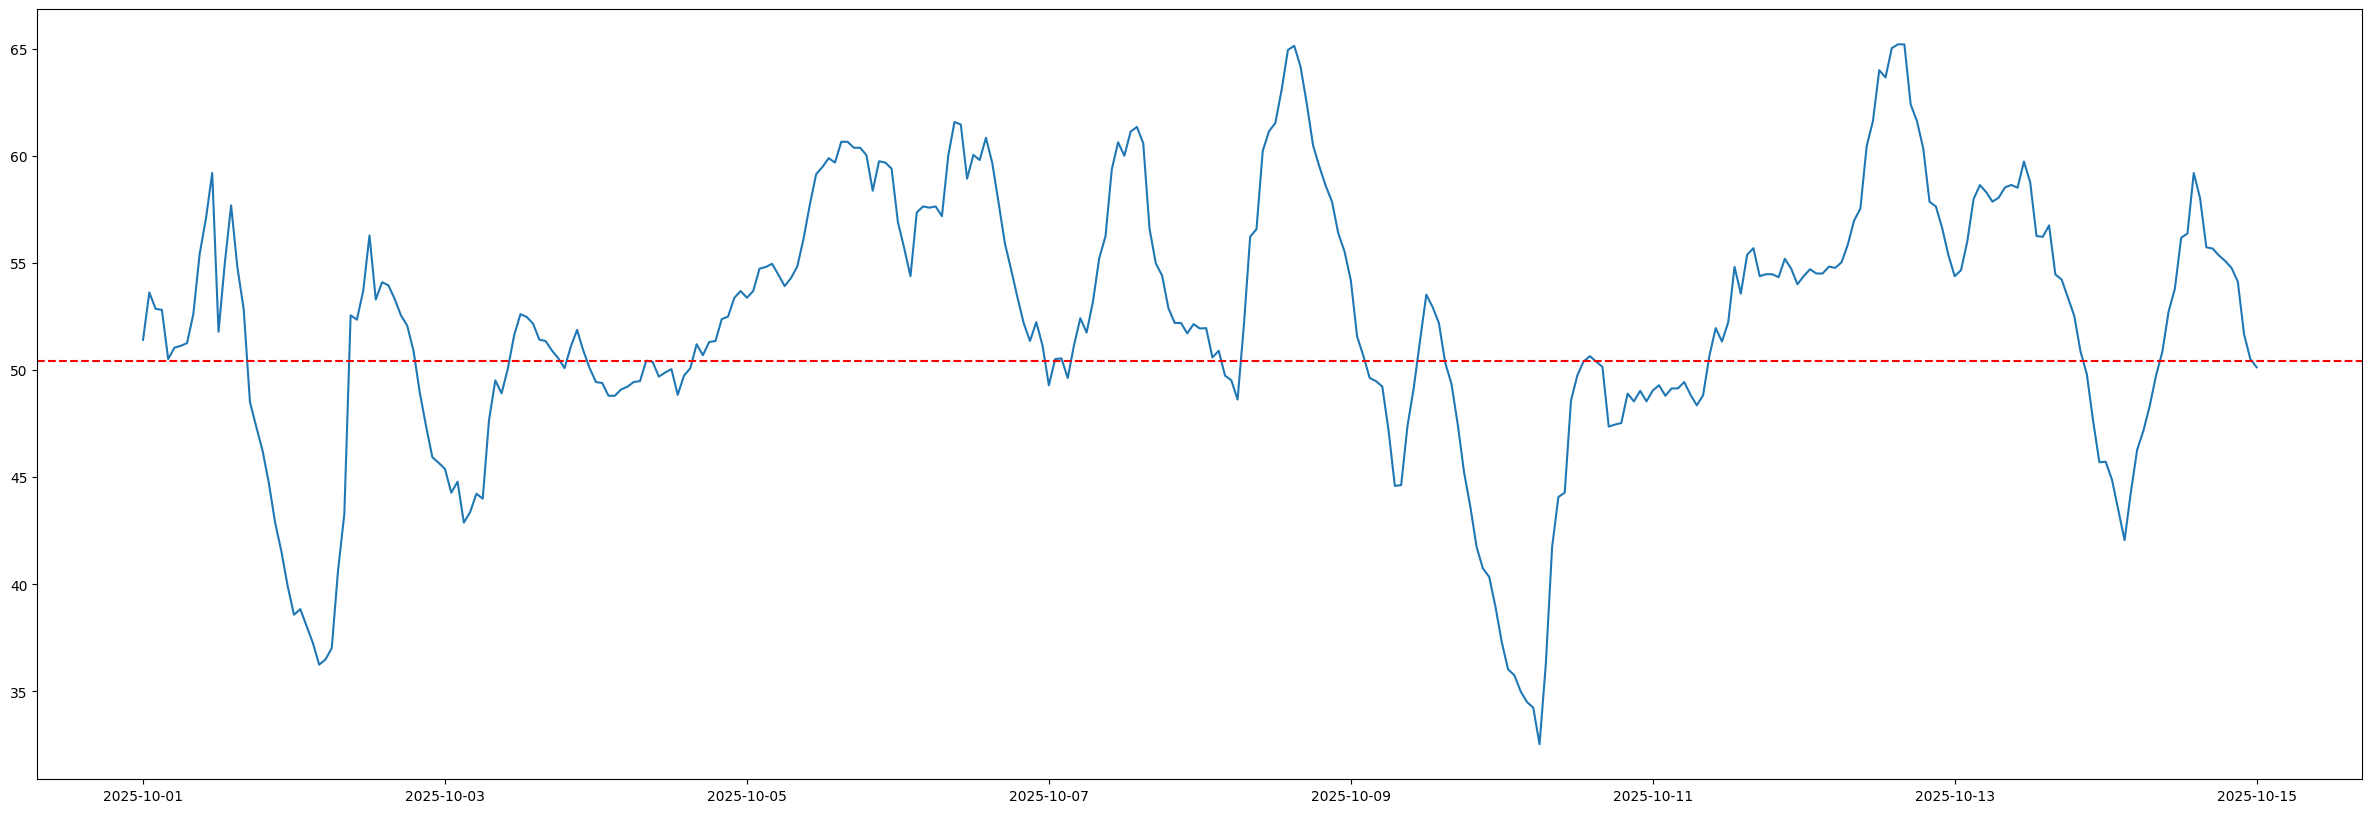

In [16]:
plt.figure(figsize=(30, 10))
plt.plot(df_10_head['年月日時'], df_10_head['エンタルピー'])
plt.axhline(y=50.42, color='red', linestyle='--')
plt.show()

# 10月の前半の1-7日のエンタルピ

In [17]:
df_10_head_0107 = df[(df['年月日時'] >= '2025-10-01') & (df['年月日時'] <= '2025-10-07')]
df_10_head_0107

,年月日時,気温(℃),相対湿度(％),エンタルピー
6551,2025-10-01 00:00:00,20.0,84.0,51.412782
6552,2025-10-01 01:00:00,20.1,89.0,53.622981
6553,2025-10-01 02:00:00,20.1,87.0,52.858729
6554,2025-10-01 03:00:00,19.6,91.0,52.808866
6555,2025-10-01 04:00:00,18.4,95.0,50.512626
...,...,...,...,...
6691,2025-10-06 20:00:00,19.4,91.0,52.185830
6692,2025-10-06 21:00:00,18.9,93.0,51.357115
6693,2025-10-06 22:00:00,19.3,92.0,52.239373
6694,2025-10-06 23:00:00,18.6,95.0,51.130149


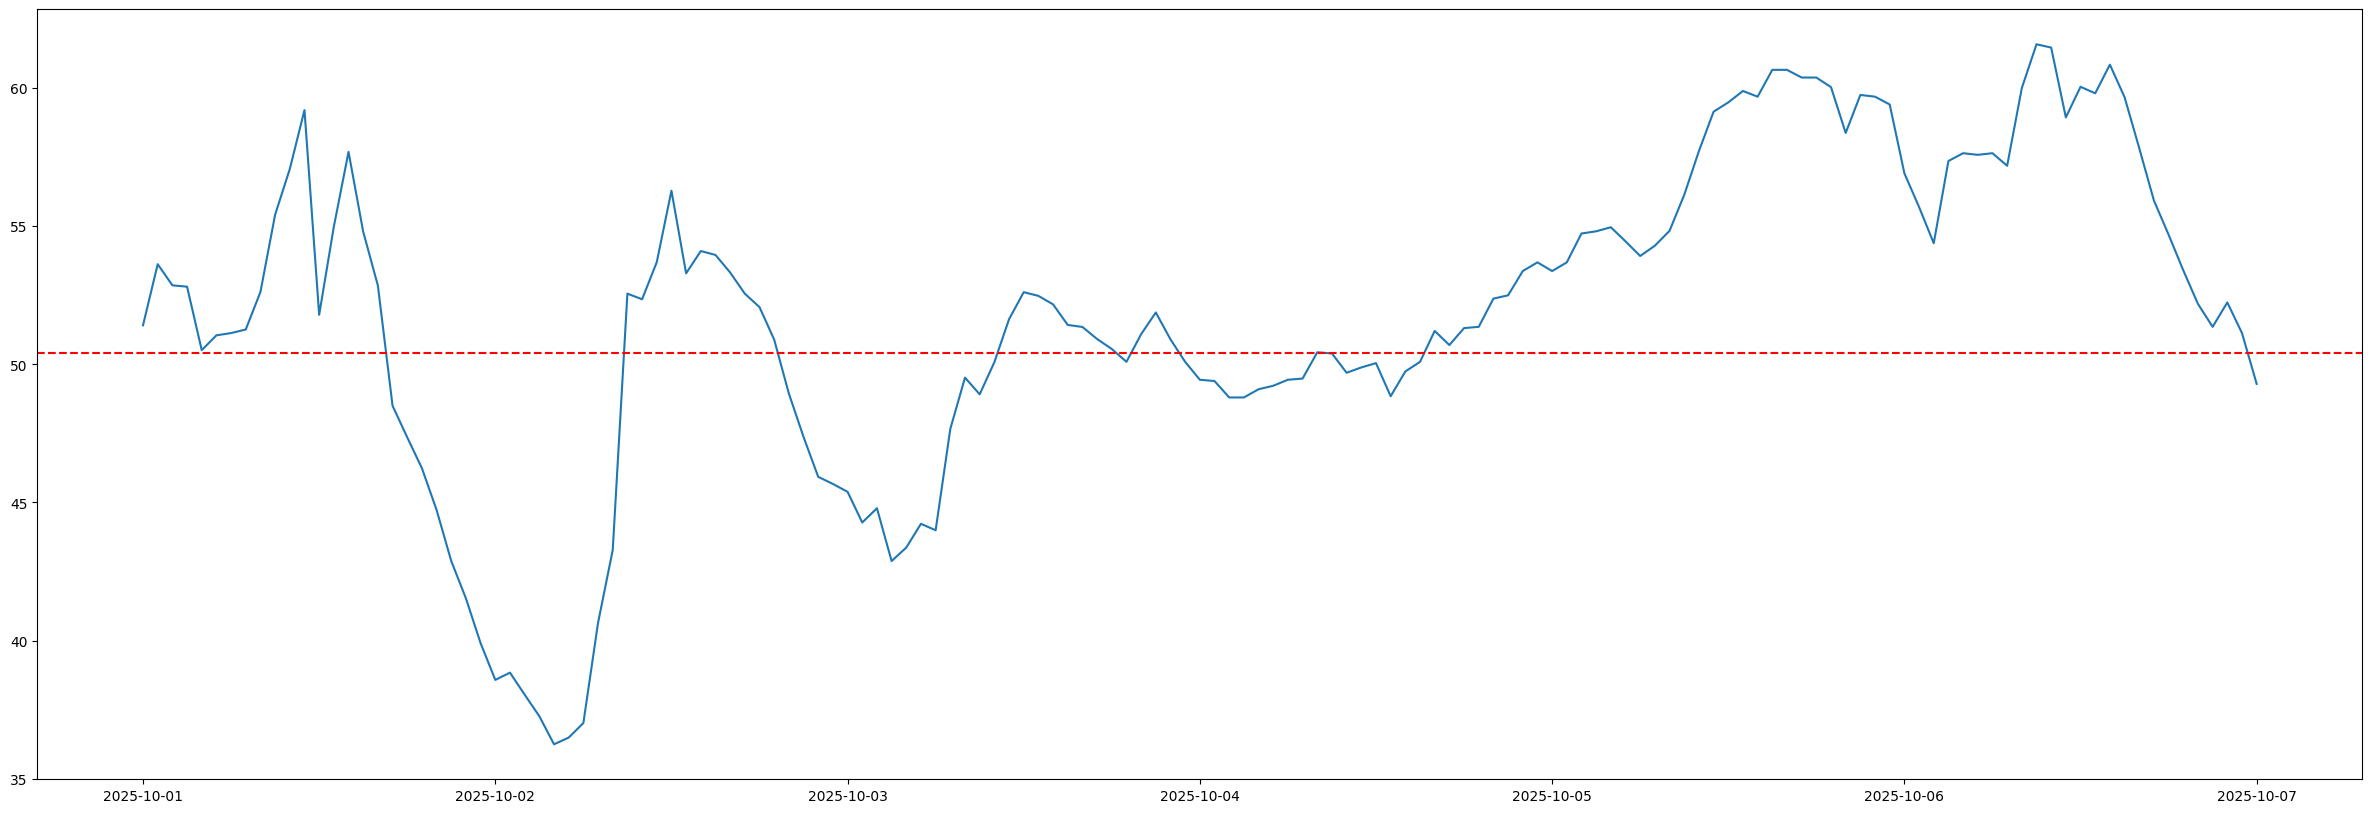

In [18]:
plt.figure(figsize=(30, 10))
plt.plot(df_10_head_0107['年月日時'], df_10_head_0107['エンタルピー'])
plt.axhline(y=50.42, color='red', linestyle='--')
plt.show()

# 10月の前半の7-15日のエンタルピ

In [19]:
df_10_head_0715 = df[(df['年月日時'] >= '2025-10-07') & (df['年月日時'] <= '2025-10-15')]
df_10_head_0715

,年月日時,気温(℃),相対湿度(％),エンタルピー
6695,2025-10-07 00:00:00,18.0,95.0,49.291958
6696,2025-10-07 01:00:00,18.4,95.0,50.512626
6697,2025-10-07 02:00:00,18.3,96.0,50.546386
6698,2025-10-07 03:00:00,18.0,96.0,49.625987
6699,2025-10-07 04:00:00,18.5,96.0,51.166023
...,...,...,...,...
6883,2025-10-14 20:00:00,20.1,92.0,54.770720
6884,2025-10-14 21:00:00,19.9,92.0,54.130397
6885,2025-10-14 22:00:00,19.0,93.0,51.666706
6886,2025-10-14 23:00:00,18.4,95.0,50.512626


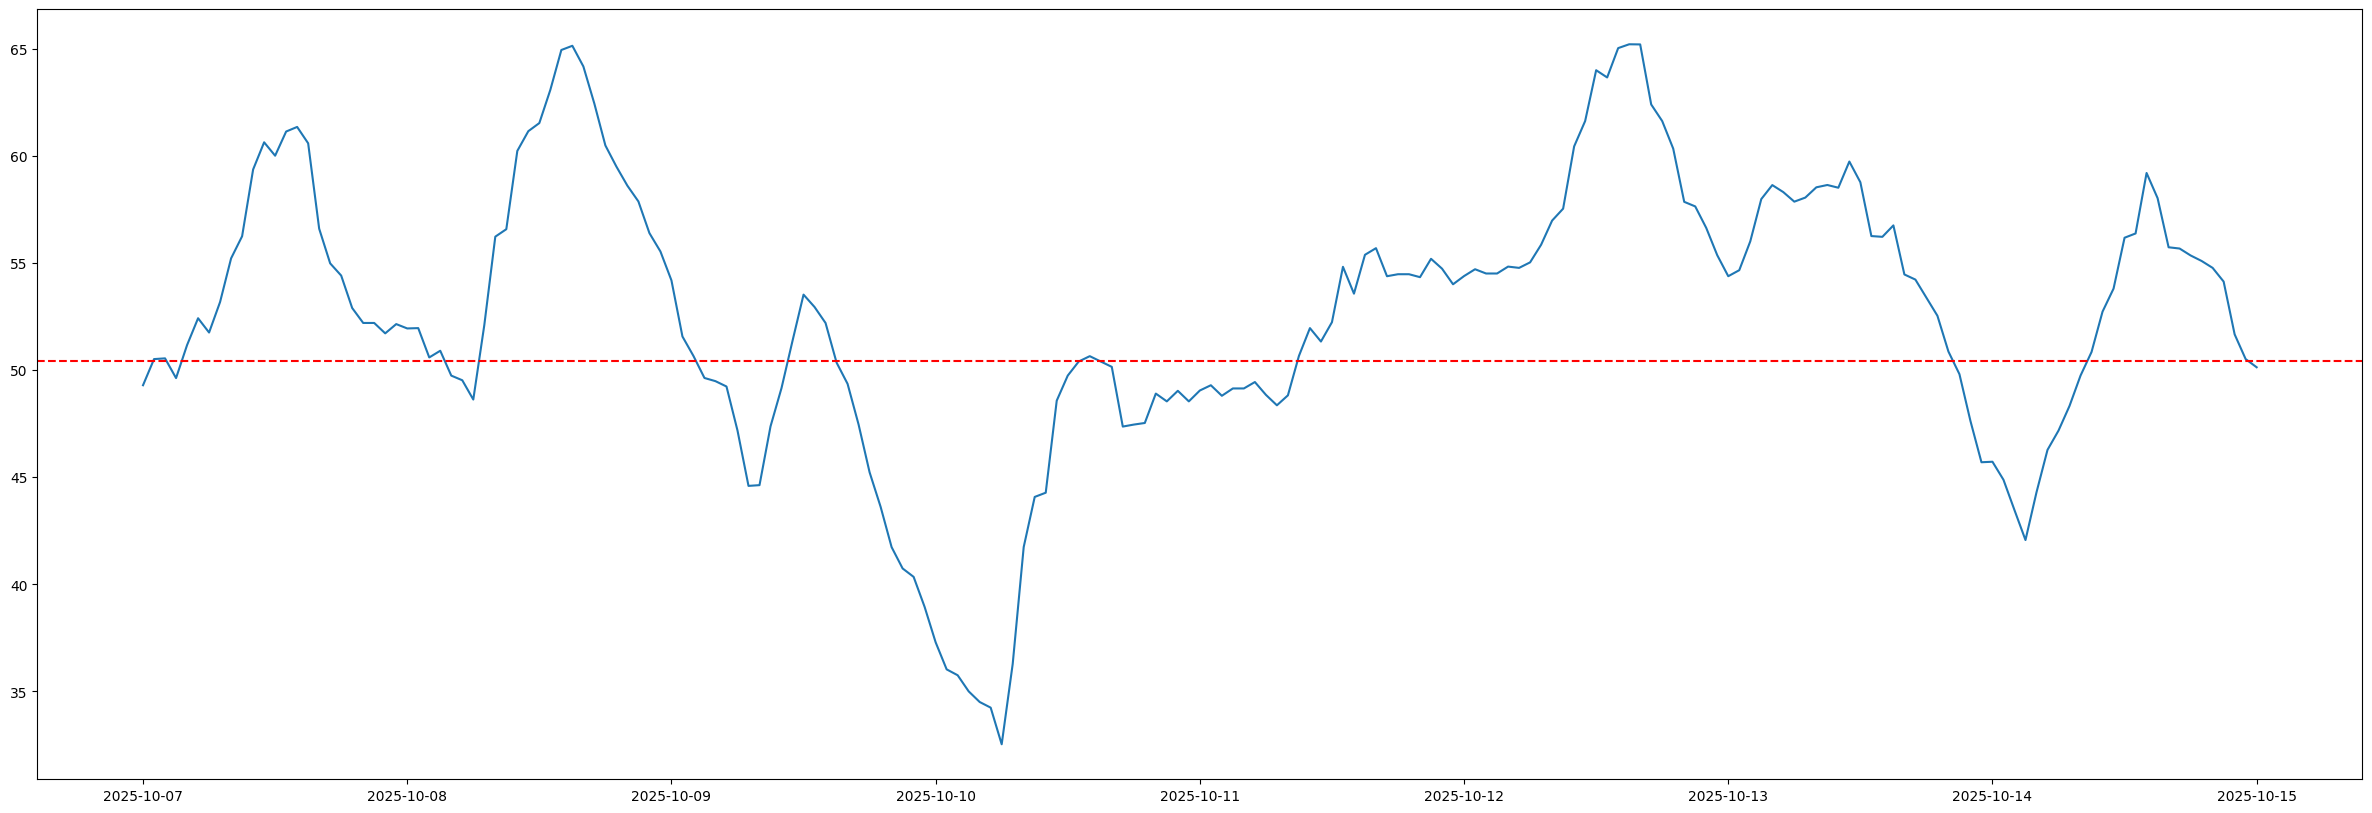

In [20]:
plt.figure(figsize=(30, 10))
plt.plot(df_10_head_0715['年月日時'], df_10_head_0715['エンタルピー'])
plt.axhline(y=50.42, color='red', linestyle='--')
plt.show()

# 10月の後半のエンタルピ

In [21]:
df_10_tail = df[(df['年月日時'] >= '2025-10-15') & (df['年月日時'] <= '2025-10-30')]
df_10_tail

,年月日時,気温(℃),相対湿度(％),エンタルピー
6887,2025-10-15 00:00:00,18.5,93.0,50.130748
6888,2025-10-15 01:00:00,18.4,94.0,50.169802
6889,2025-10-15 02:00:00,18.2,95.0,49.899913
6890,2025-10-15 03:00:00,18.2,95.0,49.899913
6891,2025-10-15 04:00:00,18.1,97.0,50.267971
...,...,...,...,...
7243,2025-10-29 20:00:00,8.2,91.0,23.718657
7244,2025-10-29 21:00:00,7.6,93.0,22.810099
7245,2025-10-29 22:00:00,6.7,95.0,21.285821
7246,2025-10-29 23:00:00,6.0,96.0,20.027370


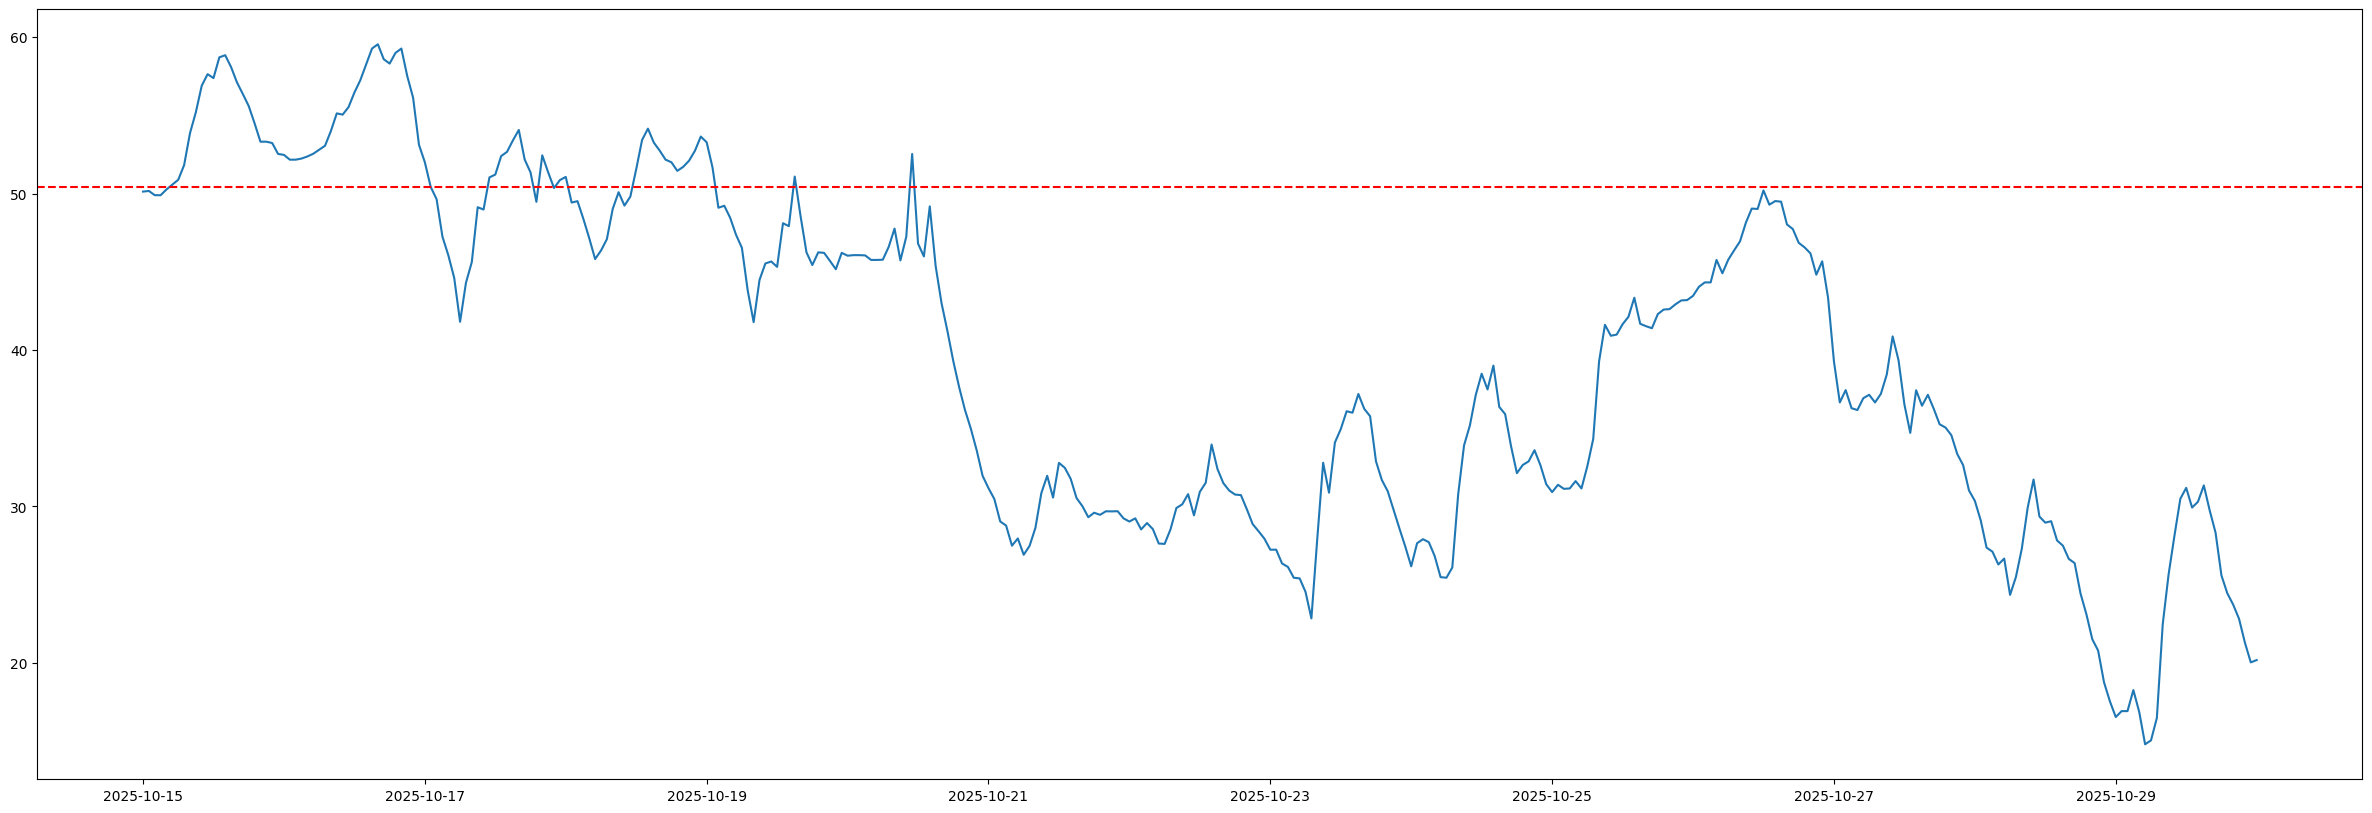

In [22]:
plt.figure(figsize=(30, 10))
plt.plot(df_10_tail['年月日時'], df_10_tail['エンタルピー'])
plt.axhline(y=50.42, color='red', linestyle='--')
plt.show()

# 10月の後半の15-22日のエンタルピ

In [23]:
df_10_tail_1522 = df[(df['年月日時'] >= '2025-10-15') & (df['年月日時'] <= '2025-10-22')]
df_10_tail_1522

,年月日時,気温(℃),相対湿度(％),エンタルピー
6887,2025-10-15 00:00:00,18.5,93.0,50.130748
6888,2025-10-15 01:00:00,18.4,94.0,50.169802
6889,2025-10-15 02:00:00,18.2,95.0,49.899913
6890,2025-10-15 03:00:00,18.2,95.0,49.899913
6891,2025-10-15 04:00:00,18.1,97.0,50.267971
...,...,...,...,...
7051,2025-10-21 20:00:00,11.6,84.0,29.688640
7052,2025-10-21 21:00:00,11.5,85.0,29.681374
7053,2025-10-21 22:00:00,11.7,83.0,29.693738
7054,2025-10-21 23:00:00,11.3,85.0,29.236179


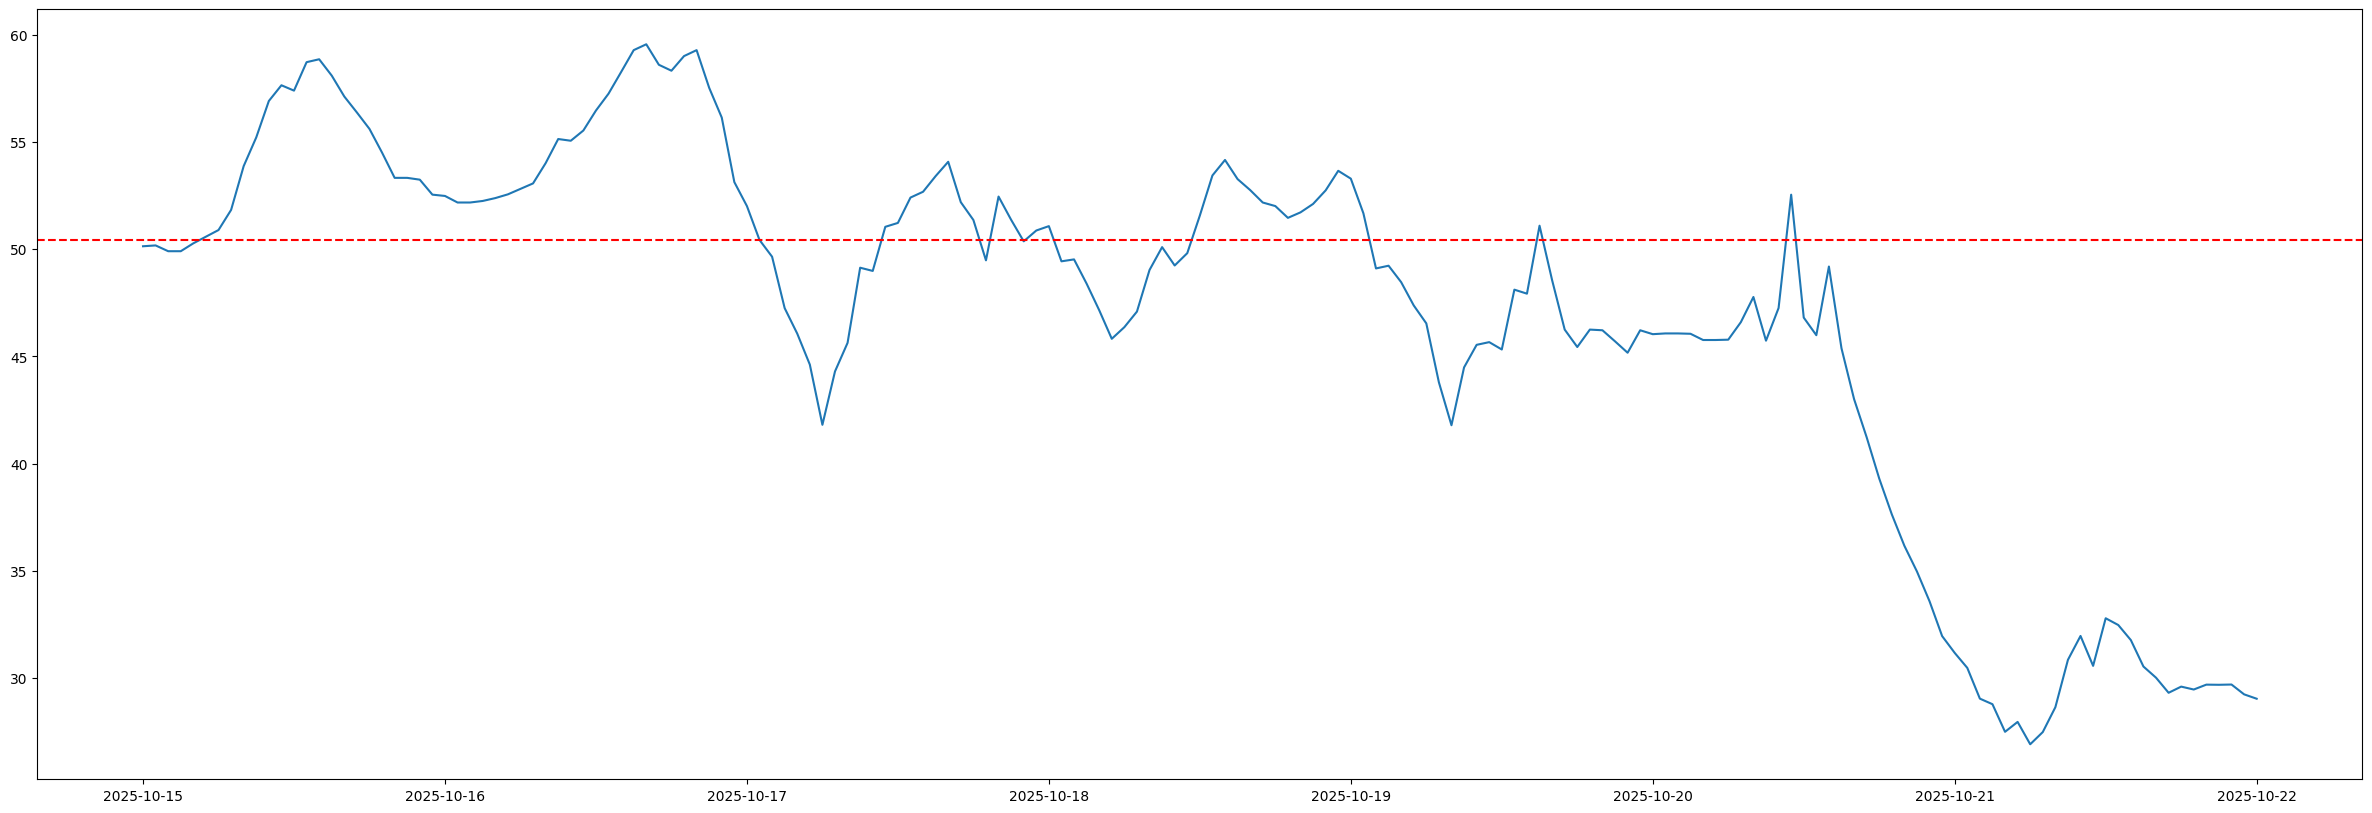

In [24]:
plt.figure(figsize=(30, 10))
plt.plot(df_10_tail_1522['年月日時'], df_10_tail_1522['エンタルピー'])
plt.axhline(y=50.42, color='red', linestyle='--')
plt.show()

# 10月の後半の22-30日のエンタルピ

In [25]:
df_10_tail_2230 = df[(df['年月日時'] >= '2025-10-22') & (df['年月日時'] <= '2025-10-30')]
df_10_tail_2230

,年月日時,気温(℃),相対湿度(％),エンタルピー
7055,2025-10-22 00:00:00,11.4,83.0,29.031471
7056,2025-10-22 01:00:00,11.3,85.0,29.236179
7057,2025-10-22 02:00:00,10.7,88.0,28.528790
7058,2025-10-22 03:00:00,10.7,90.0,28.936216
7059,2025-10-22 04:00:00,10.8,87.0,28.545861
...,...,...,...,...
7243,2025-10-29 20:00:00,8.2,91.0,23.718657
7244,2025-10-29 21:00:00,7.6,93.0,22.810099
7245,2025-10-29 22:00:00,6.7,95.0,21.285821
7246,2025-10-29 23:00:00,6.0,96.0,20.027370


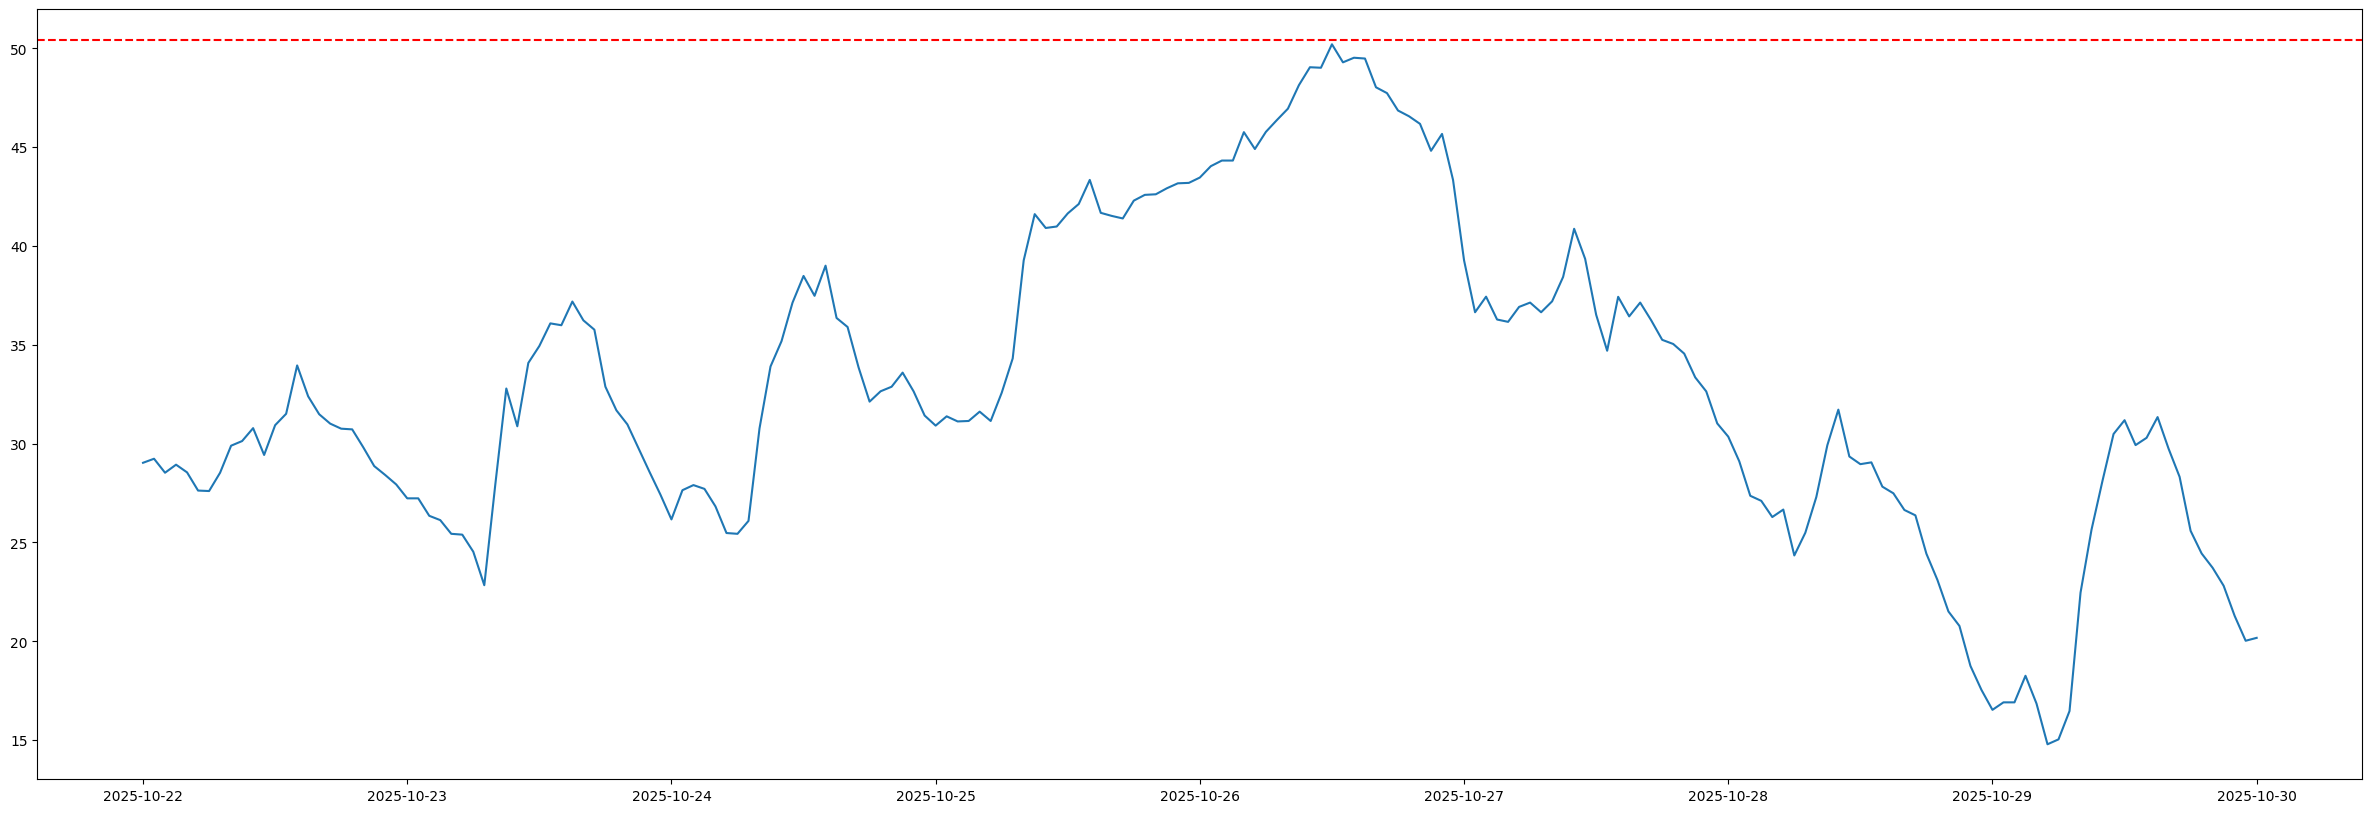

In [35]:
plt.figure(figsize=(30, 10))
plt.plot(df_10_tail_2230['年月日時'], df_10_tail_2230['エンタルピー'])
plt.axhline(y=50.42, color='red', linestyle='--')
plt.show()

# 11月のエンタルピ

In [27]:
df_11 = df[(df['年月日時'] >= '2025-11-01') & (df['年月日時'] <= '2025-11-30')]

In [28]:
df_11

,年月日時,気温(℃),相対湿度(％),エンタルピー
7295,2025-11-01 00:00:00,12.5,92.0,33.565315
7296,2025-11-01 01:00:00,12.4,89.0,32.636868
7297,2025-11-01 02:00:00,12.3,93.0,33.310712
7298,2025-11-01 03:00:00,12.4,93.0,33.552928
7299,2025-11-01 04:00:00,12.4,96.0,34.240666
...,...,...,...,...
7987,2025-11-29 20:00:00,4.2,96.0,16.531832
7988,2025-11-29 21:00:00,3.7,97.0,15.718447
7989,2025-11-29 22:00:00,3.1,97.0,14.605736
7990,2025-11-29 23:00:00,2.4,97.0,13.331826


In [30]:
df_temp_2030 = df[(df['気温(℃)'] >= 20) & (df['気温(℃)'] <= 30)]

In [31]:
df_temp_2030

,年月日時,気温(℃),相対湿度(％),エンタルピー
2005,2025-03-25 14:00:00,21.0,42.0,37.668969
2006,2025-03-25 15:00:00,22.0,37.0,37.635711
2007,2025-03-25 16:00:00,23.2,32.0,37.774381
2008,2025-03-25 17:00:00,21.8,34.0,35.997372
2051,2025-03-27 12:00:00,20.5,51.0,40.113959
...,...,...,...,...
7021,2025-10-20 14:00:00,22.2,63.0,49.184832
7022,2025-10-20 15:00:00,20.0,68.0,45.372680
7092,2025-10-23 13:00:00,20.6,40.0,36.084378
7117,2025-10-24 14:00:00,20.0,51.0,39.004540


# 10月の気温

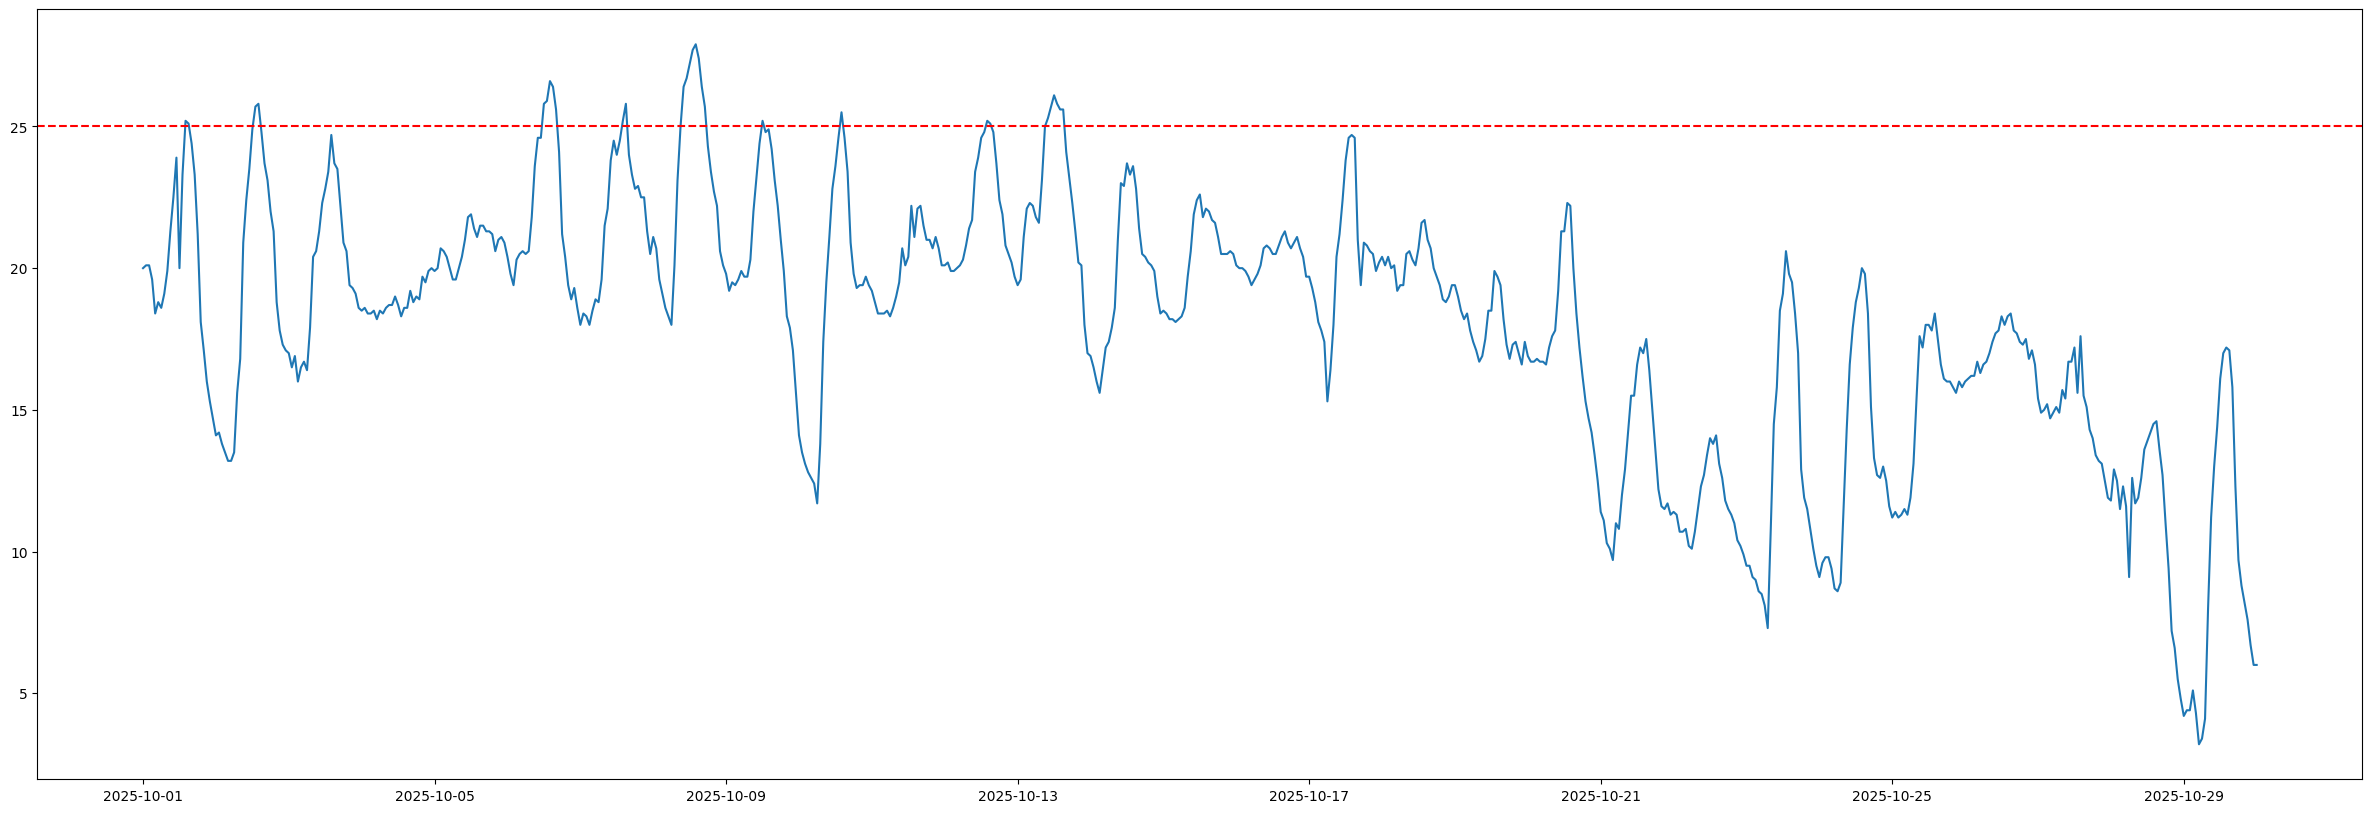

In [36]:
plt.figure(figsize=(30, 10))
plt.plot(df_10['年月日時'], df_10['気温(℃)'])
plt.axhline(y=25, color='red', linestyle='--')
plt.show()

# 9月詳細

In [42]:
df_09

,年月日時,気温(℃),相対湿度(％),エンタルピー
5831,2025-09-01 00:00:00,27.1,78.0,72.436126
5832,2025-09-01 01:00:00,26.9,79.0,72.274089
5833,2025-09-01 02:00:00,26.6,80.0,71.727293
5834,2025-09-01 03:00:00,26.4,81.0,71.548402
5835,2025-09-01 04:00:00,25.7,85.0,71.134772
...,...,...,...,...
6523,2025-09-29 20:00:00,20.9,78.0,51.756221
6524,2025-09-29 21:00:00,20.3,76.0,49.233783
6525,2025-09-29 22:00:00,18.9,86.0,48.882453
6526,2025-09-29 23:00:00,19.3,80.0,47.891225


# 9月気温

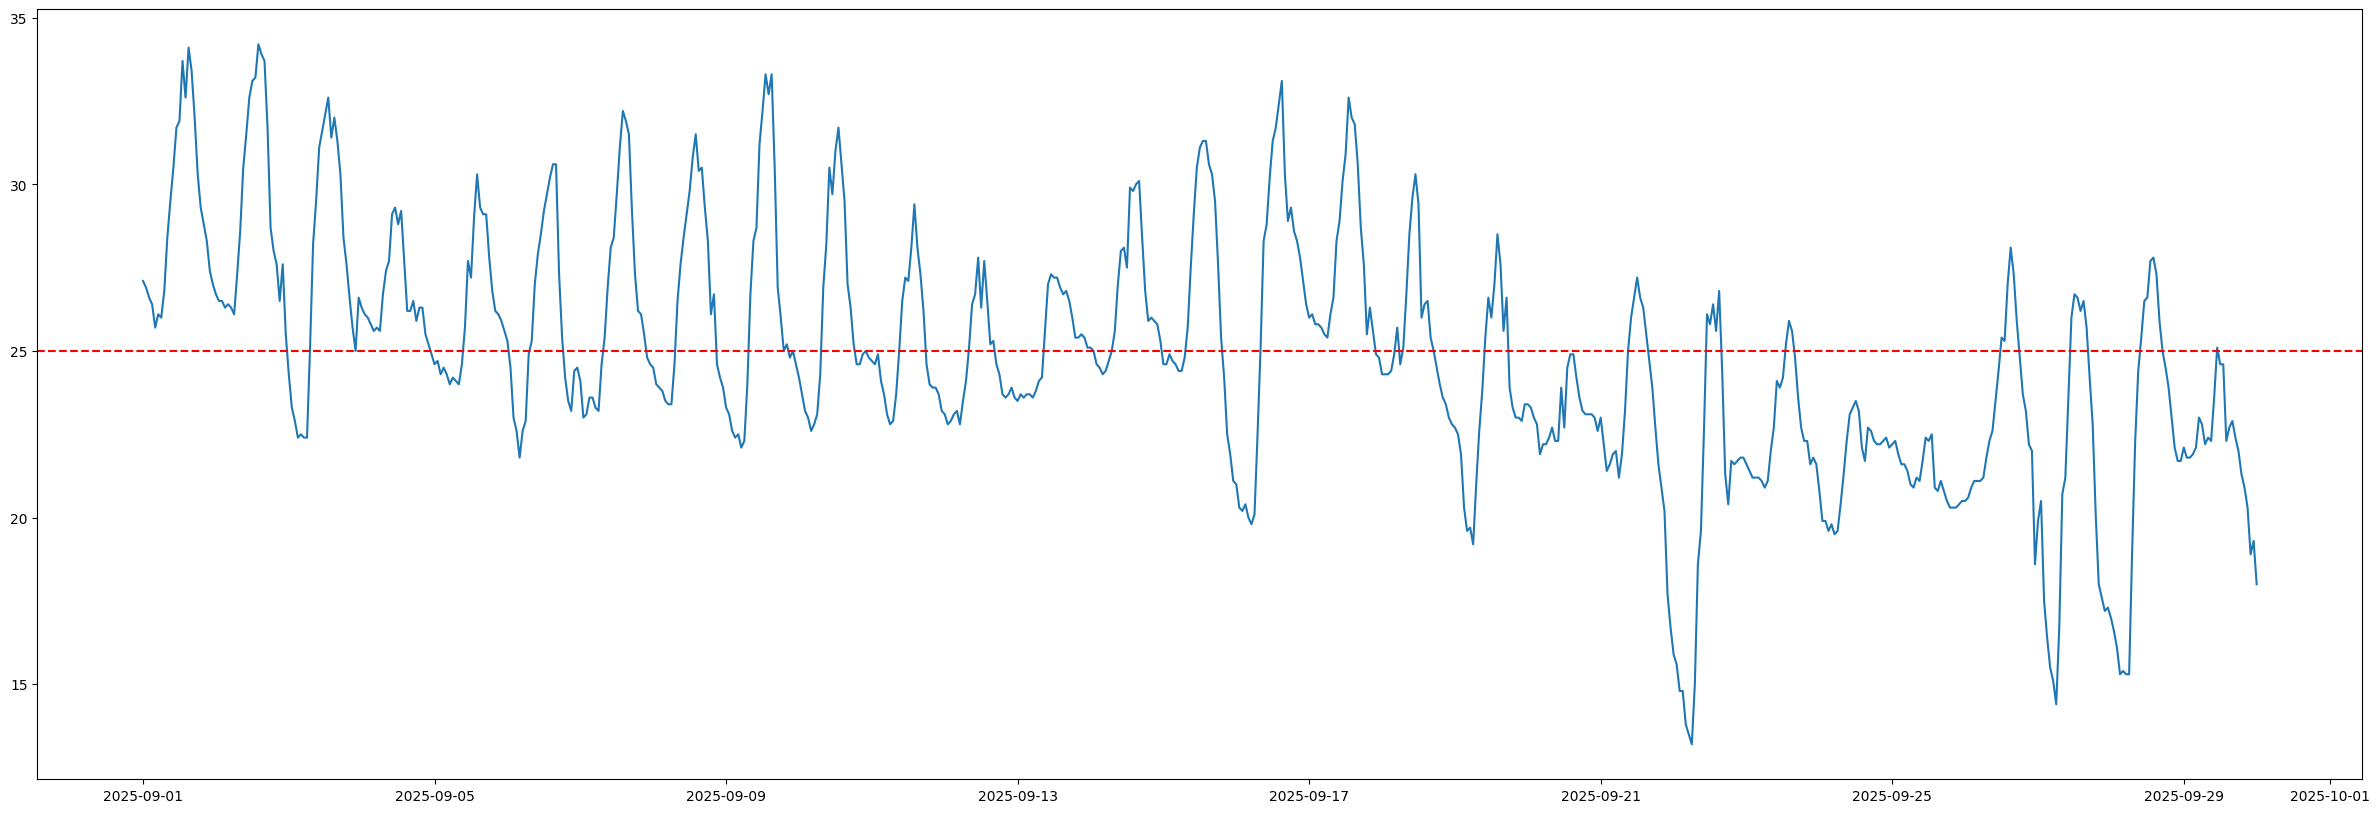

In [38]:
plt.figure(figsize=(30, 10))
plt.plot(df_09['年月日時'], df_9['気温(℃)'])
plt.axhline(y=25, color='red', linestyle='--')
plt.show()

# 9月エンタルピ

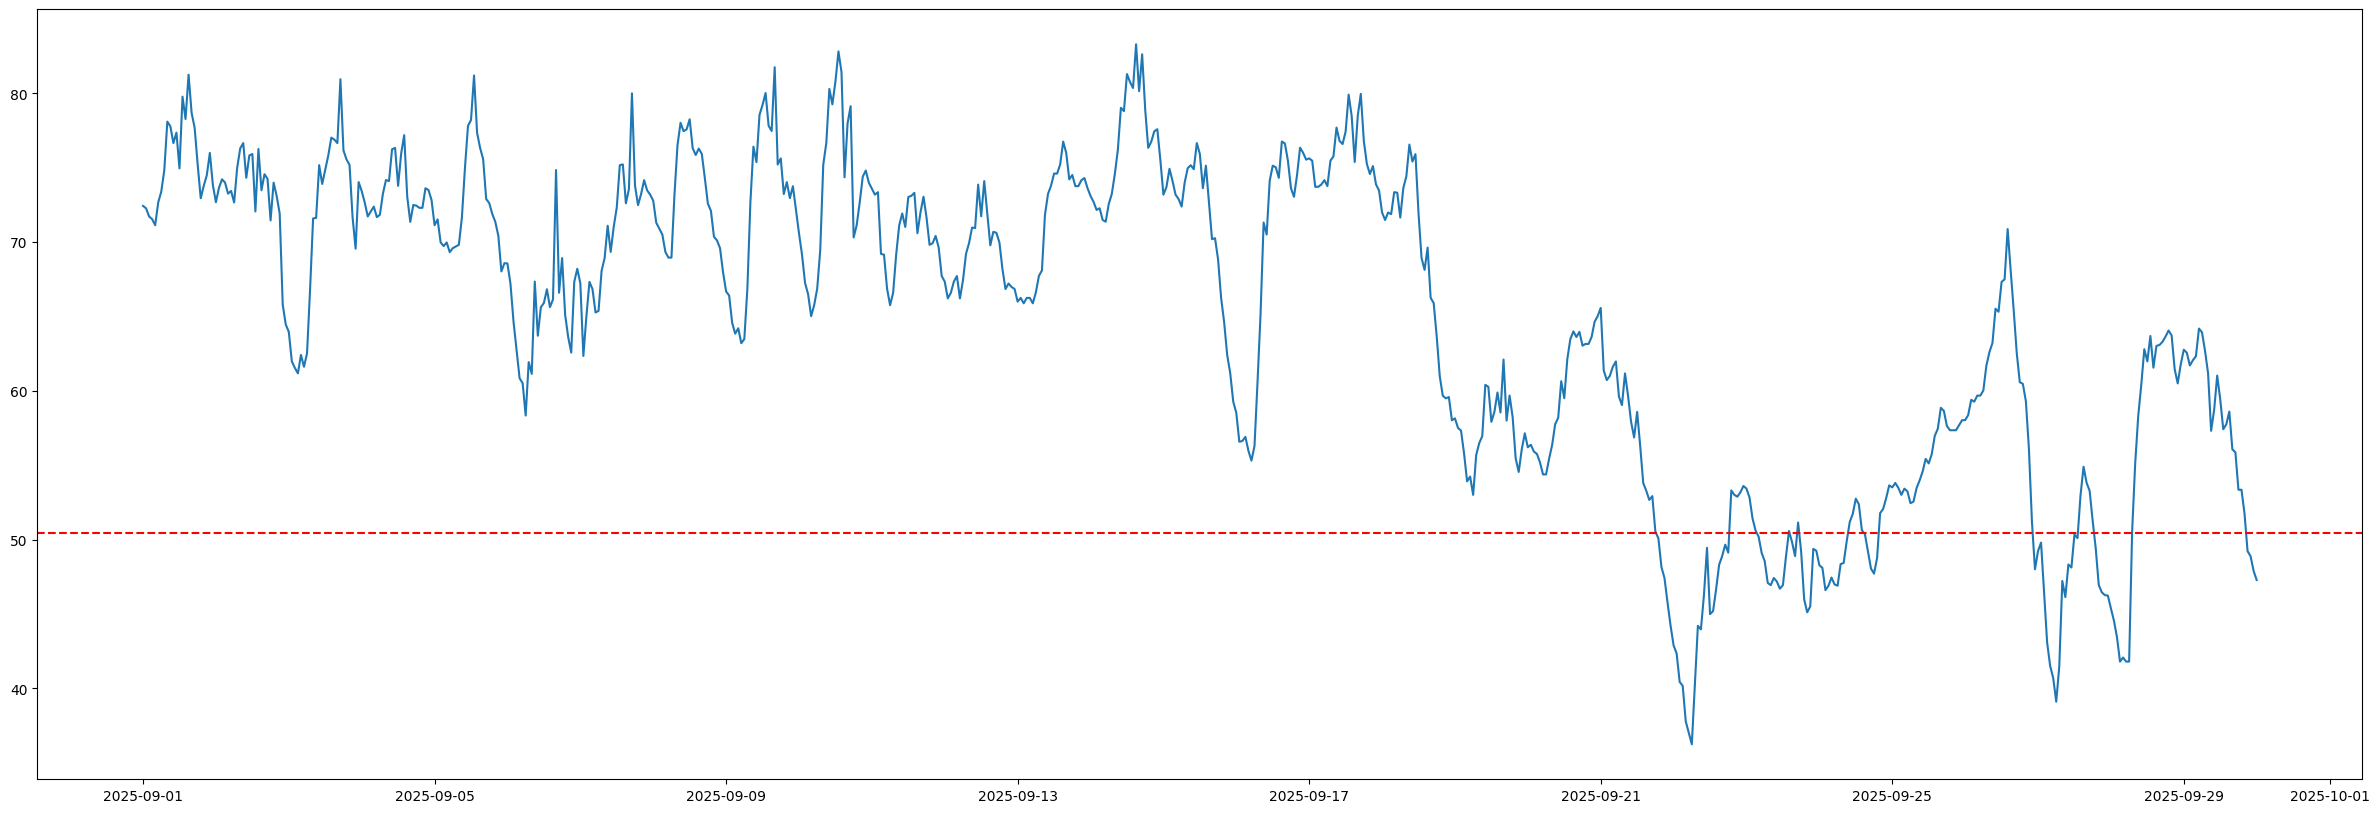

In [41]:
plt.figure(figsize=(30, 10))
plt.plot(df_09['年月日時'], df_09['エンタルピー'])
plt.axhline(y=50.42, color='red', linestyle='--')
plt.show()

# 9月15-30日

In [43]:
df_09_1530 = df[(df['年月日時'] >= '2025-09-15') & (df['年月日時'] <= '2025-09-30')]

In [44]:
df_09_1530

,年月日時,気温(℃),相対湿度(％),エンタルピー
6167,2025-09-15 00:00:00,24.6,97.0,73.191298
6168,2025-09-15 01:00:00,24.6,98.0,73.705077
6169,2025-09-15 02:00:00,24.9,98.0,74.929497
6170,2025-09-15 03:00:00,24.7,98.0,74.111481
6171,2025-09-15 04:00:00,24.6,97.0,73.191298
...,...,...,...,...
6523,2025-09-29 20:00:00,20.9,78.0,51.756221
6524,2025-09-29 21:00:00,20.3,76.0,49.233783
6525,2025-09-29 22:00:00,18.9,86.0,48.882453
6526,2025-09-29 23:00:00,19.3,80.0,47.891225


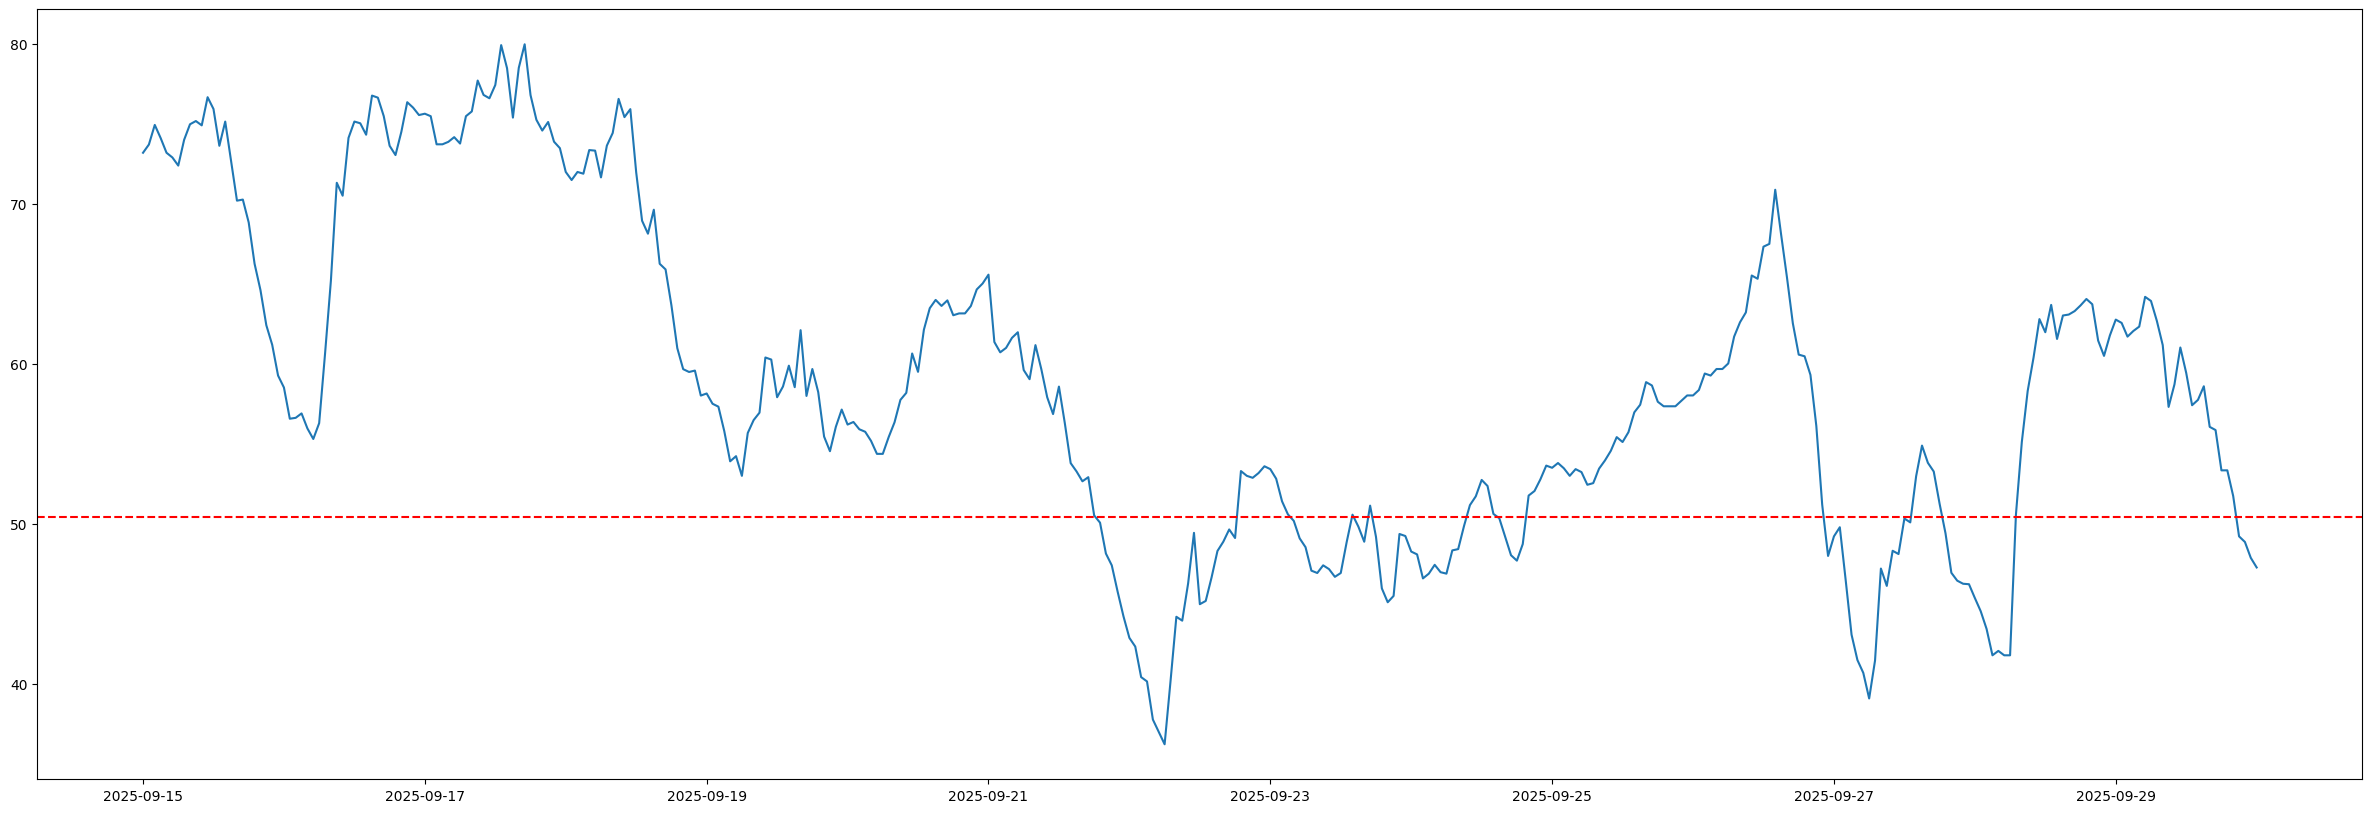

In [45]:
plt.figure(figsize=(30, 10))
plt.plot(df_09_1530['年月日時'], df_09_1530['エンタルピー'])
plt.axhline(y=50.42, color='red', linestyle='--')
plt.show()

# 9月22-30日（外気冷房条件下に入りそうな箇所）

In [46]:
df_09_2230 = df[(df['年月日時'] >= '2025-09-22') & (df['年月日時'] <= '2025-09-30')]

In [47]:
df_09_2230

,年月日時,気温(℃),相対湿度(％),エンタルピー
6335,2025-09-22 00:00:00,15.9,94.0,42.893079
6336,2025-09-22 01:00:00,15.6,95.0,42.349988
6337,2025-09-22 02:00:00,14.8,96.0,40.442412
6338,2025-09-22 03:00:00,14.8,95.0,40.172584
6339,2025-09-22 04:00:00,13.8,96.0,37.792148
...,...,...,...,...
6523,2025-09-29 20:00:00,20.9,78.0,51.756221
6524,2025-09-29 21:00:00,20.3,76.0,49.233783
6525,2025-09-29 22:00:00,18.9,86.0,48.882453
6526,2025-09-29 23:00:00,19.3,80.0,47.891225


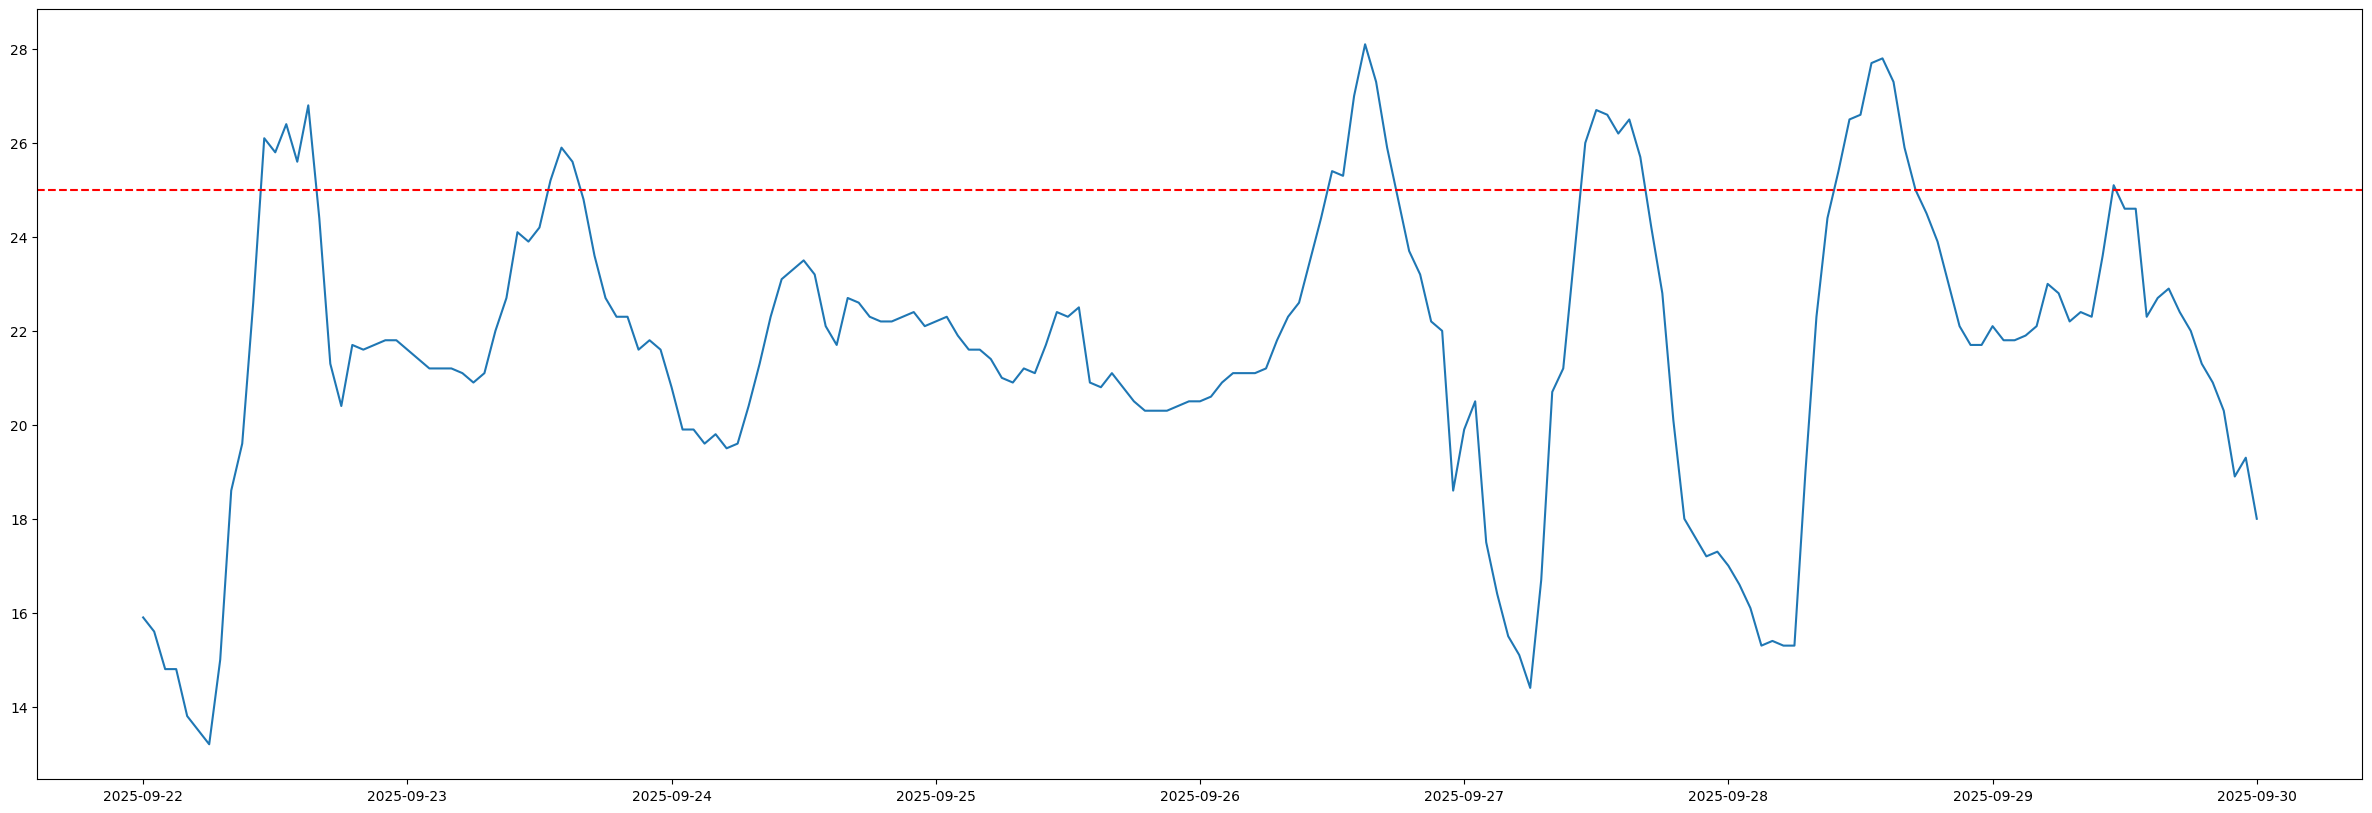

In [50]:
plt.figure(figsize=(30, 10))
plt.plot(df_09_2230['年月日時'], df_09_2230['気温(℃)'])
plt.axhline(y=25, color='red', linestyle='--')
plt.show()

#気温

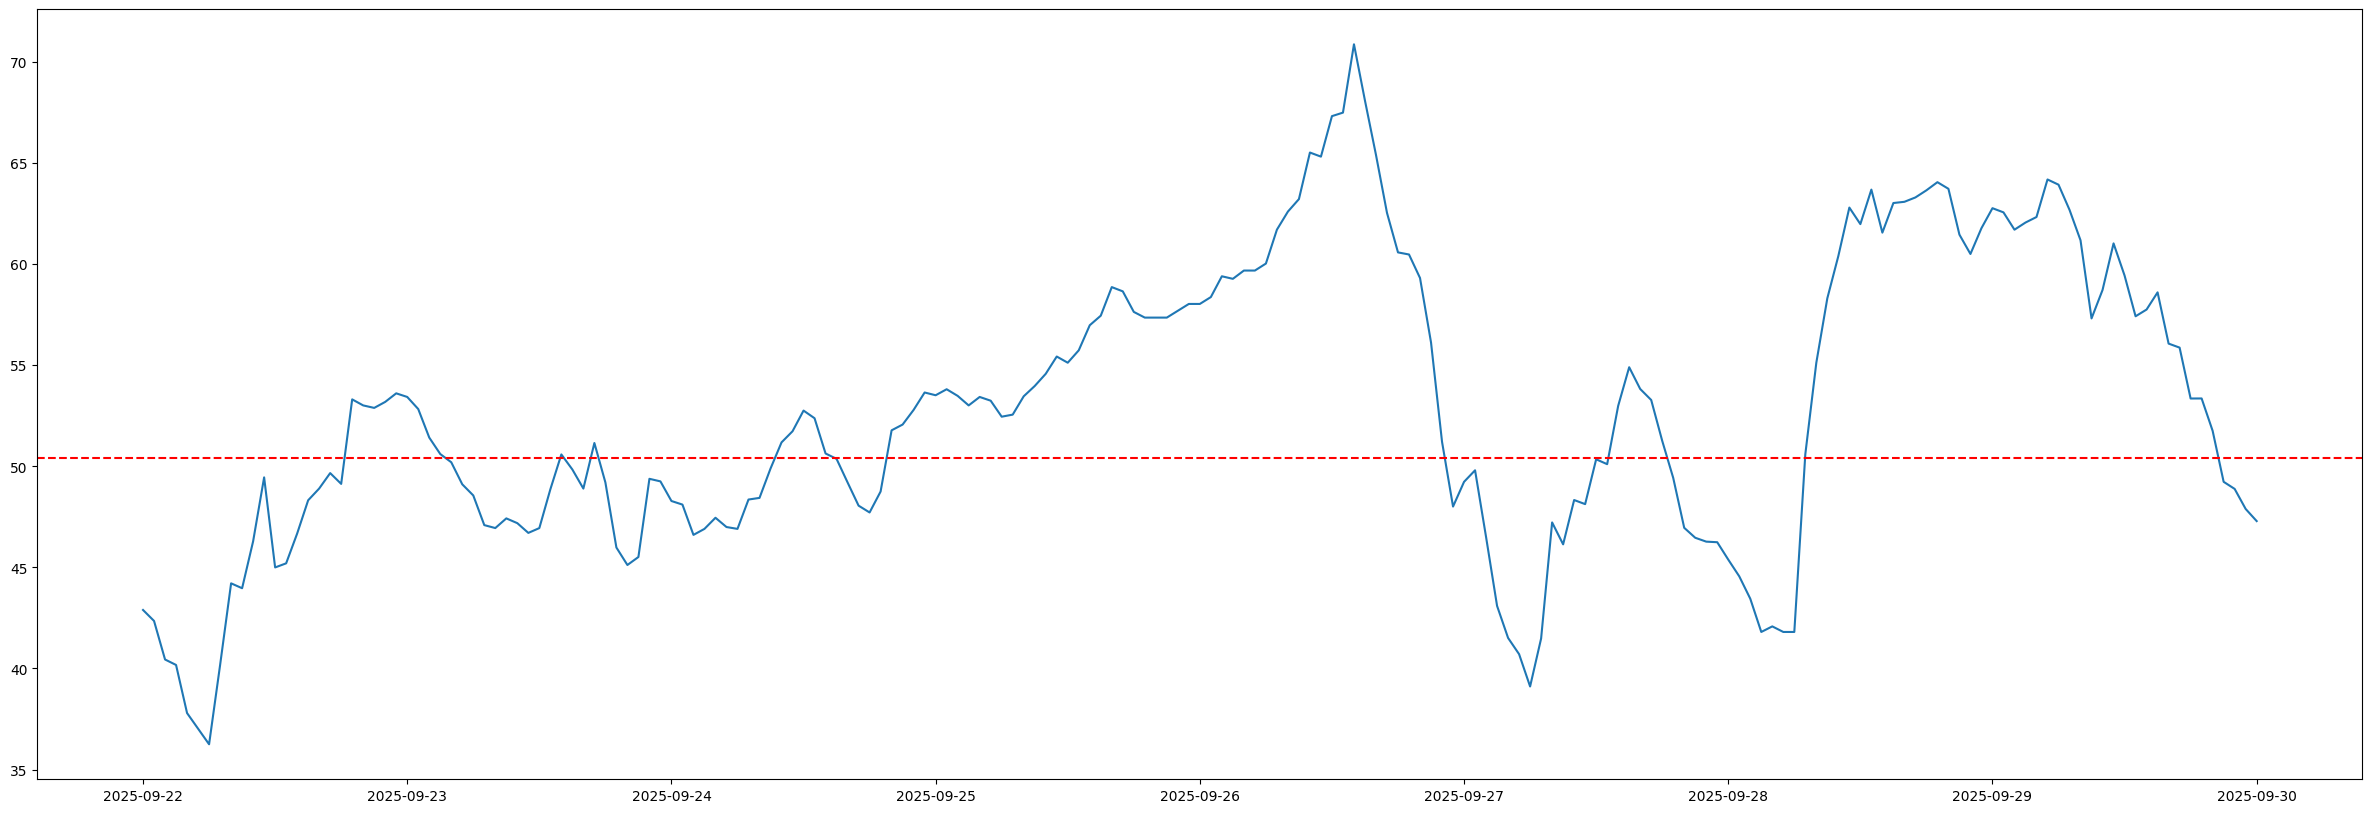

In [52]:
plt.figure(figsize=(30, 10))
plt.plot(df_09_2230['年月日時'], df_09_2230['エンタルピー'])
plt.axhline(y=50.42, color='red', linestyle='--')
plt.show()

#エンタルピ